# Weekly Context + QQQ Final Capacity-and-Threshold

Final controlled experiment for the 19 June recap. The weekly target is unchanged. The notebook now fits a common-feature LSTM, fits a benchmark HMM on the same technical/VIX/QQQ feature family, and compares the common LSTM with HMM-LSTM variants, including a recession/expansion Markov-chain realization from NBER `USREC`. All outputs are written under `outputs/weekly_context_lstm_qqq_final/`.

## 1. Imports, flags, and final grids

In [1]:
from __future__ import annotations

import os
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from sklearn.metrics import accuracy_score, balanced_accuracy_score, cohen_kappa_score, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from weekly_lstm_architecture import WeeklyLSTMConfig, build_weekly_lstm_classifier, get_weekly_callbacks, set_global_seed

plt.style.use("default")
pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 240)

SEED = 5
set_global_seed(SEED)
PROJECT_ROOT = Path.cwd()

CONTEXT_UNSCALED_INPUT_PATH = PROJECT_ROOT / "outputs" / "weekly_context" / "model_df_weekly_with_vol_context.parquet"
CONTEXT_SCALED_REFERENCE_PATH = PROJECT_ROOT / "outputs" / "weekly_context" / "model_df_weekly_with_vol_context_scaled.parquet"
HMM_FEATURE_SOURCE_PATH = PROJECT_ROOT / "outputs" / "weekly_hmm" / "weekly_hmm_regime_features.parquet"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "weekly_context_lstm_qqq_final"
PLOTS_DIR = OUTPUT_DIR / "plots"
MODEL_DIR = PROJECT_ROOT / "models" / "weekly_context_lstm_qqq_final"
for directory in [OUTPUT_DIR, PLOTS_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RUN_LEGACY_QQQ_EXPERIMENT = False
RUN_FINAL_CAPACITY_ABLATION = True
RUN_FULL_FINAL_GRID = True

TICKERS = ["AAPL", "IBM", "MSFT"]
LOOKBACK_GRID = [4, 8, 12]
TARGET_COL = "Target_State_Binary"
MERGE_KEYS = ["Ticker", "Date", "Target_Date", "Split"]
MAX_EPOCHS = 80
PATIENCE = 12
BATCH_SIZE = 16
THRESHOLDS = np.round(np.arange(0.05, 0.951, 0.01), 2)
FIXED_THRESHOLD = 0.50
LOW_PROBABILITY_STD_CUTOFF = 0.02
LOSS_FUNCTION = "binary_crossentropy"
USE_FOCAL_LOSS = False
WEEKLY_RESAMPLE_RULE = "W-FRI"
LARGE_GAP_DAYS = 14
MARKET_CONTEXT_TICKERS = {"QQQ": "QQQ"}
NBER_USREC_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=USREC"
N_STATES = 2
HMM_N_ITER = 500
HMM_TOL = 1e-4
HMM_MIN_COVAR = 1e-4
MARKOV_SMOOTHING = 1.0
TARGET_PROBABILITY_SMOOTHING = 2.0
COMMON_RECAP_FEATURE_CONFIG = "vol_market_context_qqq"
RECESSION_HMM_LSTM_FEATURE_CONFIG = "vol_market_context_qqq_recession_hmm"
STOCK_HMM_LSTM_FEATURE_CONFIG = "vol_market_context_qqq_hmm"

ARCHITECTURE_CONFIGS = {
    "small_original": {"lstm_units": (16,), "dense_units": (8,), "dropout": 0.20, "learning_rate": 1e-3},
    "medium": {"lstm_units": (32,), "dense_units": (16,), "dropout": 0.10, "learning_rate": 5e-4},
    "stacked": {"lstm_units": (64, 32), "dense_units": (16,), "dropout": 0.10, "learning_rate": 5e-4},
}
if not RUN_FULL_FINAL_GRID:
    ARCHITECTURE_CONFIGS = {k: ARCHITECTURE_CONFIGS[k] for k in ["small_original", "medium"]}

HMM_REFITTED_IN_THIS_NOTEBOOK = False
BENCHMARK_HMM_FITTED_IN_THIS_NOTEBOOK = False
RECESSION_EXPANSION_MARKOV_CHAIN_USED = False
BACKWARD_FILL_METHOD_USED = False
VALIDATION_THRESHOLDS_USED_VALIDATION_ONLY = True
TEST_DATA_USED_FOR_MODEL_SELECTION = False
BOTH_THRESHOLD_TYPES_EVALUATED = False
SEQUENCE_CONTINUITY_CHECKS_PERFORMED = False
WEEKLY_TARGET_UNCHANGED = False

print(f"Project root: {PROJECT_ROOT}")
print(f"Final output directory: {OUTPUT_DIR}")
print(f"Run full final grid: {RUN_FULL_FINAL_GRID}")

Project root: d:\BA_year_3\honour project
Final output directory: d:\BA_year_3\honour project\outputs\weekly_context_lstm_qqq_final
Run full final grid: True


## 2. Final feature configurations

In [2]:
BASELINE_WEEKLY_FEATURES = [
    "Weekly_Log_Return", "Weekly_Open_Close_Log_Return", "Weekly_High_Low_Range", "Weekly_Volume_Change",
    "Rolling_Vol_4", "Rolling_Vol_12", "Rolling_Vol_26", "Momentum_4", "Momentum_12", "Momentum_26",
    "MA_Gap_4", "MA_Gap_12", "MA_Gap_26", "Drawdown_12", "Drawdown_26",
]
VOL_CONTEXT_FEATURES_COMPACT = [
    "VIX_Close", "VIX_Log_Change", "VIX_ZScore_12", "VIX_Above_MA_12",
    "VXN_Close", "VXN_Log_Change", "VXN_ZScore_12", "VXN_Above_MA_12", "VXN_minus_VIX", "VXN_to_VIX",
]
QQQ_ABSOLUTE_FEATURES = [
    "QQQ_Weekly_Log_Return", "QQQ_Open_Close_Log_Return", "QQQ_High_Low_Range", "QQQ_Volume_Change",
    "QQQ_Rolling_Vol_4", "QQQ_Rolling_Vol_12", "QQQ_Momentum_4", "QQQ_Momentum_12", "QQQ_MA_Gap_4", "QQQ_MA_Gap_12",
]
QQQ_RELATIVE_FEATURES = ["Relative_Return_vs_QQQ", "Relative_Momentum_4_vs_QQQ", "Relative_Momentum_12_vs_QQQ", "Relative_Vol_12_vs_QQQ"]
MARKET_CONTEXT_FEATURES_QQQ = QQQ_ABSOLUTE_FEATURES + QQQ_RELATIVE_FEATURES
RECAP_COMMON_FEATURES = BASELINE_WEEKLY_FEATURES + VOL_CONTEXT_FEATURES_COMPACT + MARKET_CONTEXT_FEATURES_QQQ

STOCK_HMM_FEATURES = ["HMM_Bullish_Prob_Next", "HMM_Positive_Return_Prob_Next"]
HMM_FEATURES = STOCK_HMM_FEATURES
NBER_HMM_FEATURES = ["NBER_Expansion_Prob_Next", "NBER_Positive_Return_Prob_Next"]

FEATURE_CONFIGS = {
    "technical_only": BASELINE_WEEKLY_FEATURES,
    "vol_context_compact": BASELINE_WEEKLY_FEATURES + VOL_CONTEXT_FEATURES_COMPACT,
    "hmm_informed": BASELINE_WEEKLY_FEATURES + STOCK_HMM_FEATURES,
    "vol_context_compact_hmm": BASELINE_WEEKLY_FEATURES + VOL_CONTEXT_FEATURES_COMPACT + STOCK_HMM_FEATURES,
    "vol_market_context_qqq": RECAP_COMMON_FEATURES,
    "vol_market_context_qqq_hmm": RECAP_COMMON_FEATURES + STOCK_HMM_FEATURES,
    "vol_market_context_qqq_recession_hmm": RECAP_COMMON_FEATURES + NBER_HMM_FEATURES,
}
EXPECTED_FEATURE_COUNTS = {
    "technical_only": 15,
    "vol_context_compact": 25,
    "hmm_informed": 17,
    "vol_context_compact_hmm": 27,
    "vol_market_context_qqq": 39,
    "vol_market_context_qqq_hmm": 41,
    "vol_market_context_qqq_recession_hmm": 41,
}
LEAKAGE_COLUMNS = {
    "Ticker", "Date", "Target_Date", "Split", TARGET_COL, "Target_State", "Next_Week_Log_Return",
    "HMM_State", "HMM_Regime_Label", "NBER_Recession_State", "NBER_Expansion_State",
    "NBER_Target_Recession_State", "NBER_Target_Expansion_State",
}

for name, cols in FEATURE_CONFIGS.items():
    duplicated = pd.Series(cols)[pd.Series(cols).duplicated()].tolist()
    if duplicated:
        raise ValueError(f"{name} has duplicate features: {duplicated}")
    leakage = sorted(set(cols).intersection(LEAKAGE_COLUMNS))
    if leakage:
        raise ValueError(f"{name} uses leakage columns: {leakage}")
    if len(cols) != EXPECTED_FEATURE_COUNTS[name]:
        raise ValueError(f"{name} expected {EXPECTED_FEATURE_COUNTS[name]} features, found {len(cols)}")
if any(col.startswith("HMM_") and col not in STOCK_HMM_FEATURES for cols in FEATURE_CONFIGS.values() for col in cols):
    raise ValueError("Only saved next-step stock-HMM probabilities may be used from the stock HMM.")
if any(col.startswith("NBER_") and col not in NBER_HMM_FEATURES for cols in FEATURE_CONFIGS.values() for col in cols):
    raise ValueError("Only next-step NBER recession/expansion Markov-chain probabilities may be used as LSTM features.")

TICKER_SCALED_FEATURES = BASELINE_WEEKLY_FEATURES + QQQ_RELATIVE_FEATURES
GLOBAL_CONTEXT_FEATURES = VOL_CONTEXT_FEATURES_COMPACT + QQQ_ABSOLUTE_FEATURES
ACTIVE_ARCHITECTURES = list(ARCHITECTURE_CONFIGS)
ACTIVE_LOOKBACKS = LOOKBACK_GRID
EXPECTED_TRAINING_RUNS = len(TICKERS) * len(ACTIVE_LOOKBACKS) * len(FEATURE_CONFIGS) * len(ACTIVE_ARCHITECTURES)

display(pd.DataFrame([{"feature_config": k, "feature_count": len(v)} for k, v in FEATURE_CONFIGS.items()]))
print(f"Recap common feature config: {COMMON_RECAP_FEATURE_CONFIG} ({len(RECAP_COMMON_FEATURES)} features)")
print(f"Recession/expansion HMM-LSTM feature config: {RECESSION_HMM_LSTM_FEATURE_CONFIG}")
print(f"Expected final training runs: {EXPECTED_TRAINING_RUNS}")


,feature_config,feature_count
0,technical_only,15
1,vol_context_compact,25
2,hmm_informed,17
3,vol_context_compact_hmm,27
4,vol_market_context_qqq,39
5,vol_market_context_qqq_hmm,41
6,vol_market_context_qqq_recession_hmm,41


Recap common feature config: vol_market_context_qqq (39 features)
Recession/expansion HMM-LSTM feature config: vol_market_context_qqq_recession_hmm
Expected final training runs: 189


## 3. Data preparation, missing-value handling, scaling, and continuity checks

In [3]:
def require_columns(df: pd.DataFrame, required_cols: list[str], name: str) -> None:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")

def normalize_yfinance_ohlcv(downloaded: pd.DataFrame, symbol: str) -> pd.DataFrame:
    if downloaded.empty:
        raise ValueError(f"No yfinance data downloaded for {symbol}.")
    data = downloaded.copy()
    if isinstance(data.columns, pd.MultiIndex):
        if symbol in data.columns.get_level_values(-1):
            data = data.xs(symbol, axis=1, level=-1, drop_level=True)
        elif symbol in data.columns.get_level_values(0):
            data = data.xs(symbol, axis=1, level=0, drop_level=True)
        else:
            data.columns = data.columns.get_level_values(0)
    required_ohlcv = ["Open", "High", "Low", "Close", "Volume"]
    require_columns(data.reset_index(), required_ohlcv, f"{symbol} yfinance data")
    data = data[required_ohlcv].copy()
    data.index = pd.to_datetime(data.index).tz_localize(None).normalize()
    return data.sort_index()

def build_qqq_weekly_features(daily_ohlcv: pd.DataFrame) -> pd.DataFrame:
    weekly = daily_ohlcv.resample(WEEKLY_RESAMPLE_RULE).agg({"Open": "first", "High": "max", "Low": "min", "Close": "last", "Volume": "sum"}).dropna(subset=["Open", "High", "Low", "Close"]).reset_index().rename(columns={"index": "Date"})
    weekly["Date"] = pd.to_datetime(weekly["Date"]).dt.normalize()
    weekly["QQQ_Log_Close"] = np.log(weekly["Close"])
    weekly["QQQ_Weekly_Log_Return"] = weekly["QQQ_Log_Close"].diff()
    weekly["QQQ_Open_Close_Log_Return"] = np.log(weekly["Close"] / weekly["Open"])
    weekly["QQQ_High_Low_Range"] = (weekly["High"] - weekly["Low"]) / weekly["Close"]
    weekly["QQQ_Log_Weekly_Volume"] = np.log(weekly["Volume"].replace(0, np.nan))
    weekly["QQQ_Volume_Change"] = weekly["QQQ_Log_Weekly_Volume"].diff()
    for window in [4, 12]:
        weekly[f"QQQ_Rolling_Vol_{window}"] = weekly["QQQ_Weekly_Log_Return"].rolling(window).std()
        weekly[f"QQQ_Momentum_{window}"] = weekly["QQQ_Weekly_Log_Return"].rolling(window).sum()
        weekly[f"QQQ_MA_Gap_{window}"] = weekly["Close"] / weekly["Close"].rolling(window).mean() - 1
    return weekly[["Date"] + QQQ_ABSOLUTE_FEATURES].replace([np.inf, -np.inf], np.nan)

def missing_rows_are_initial_warmup(group: pd.DataFrame, mask: pd.Series) -> bool:
    ordered = mask.loc[group.sort_values("Date").index].to_numpy(dtype=bool)
    if not ordered.any():
        return True
    valid_pos = np.flatnonzero(~ordered)
    if len(valid_pos) == 0:
        return False
    first_valid = int(valid_pos[0])
    return bool(ordered[:first_valid].all() and not ordered[first_valid:].any())

def build_sequence_continuity_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for ticker, group in df.groupby("Ticker", sort=True):
        group = group.sort_values("Date").copy()
        group["date_gap_days"] = group["Date"].diff().dt.days
        large_gaps = group.loc[group["date_gap_days"] > LARGE_GAP_DAYS]
        rows.append({
            "Ticker": ticker, "rows": len(group), "start_date": group["Date"].min(), "end_date": group["Date"].max(),
            "max_gap_days": float(group["date_gap_days"].max()) if group["date_gap_days"].notna().any() else 0.0,
            "large_gap_count": len(large_gaps), "large_gap_dates": ";".join(large_gaps["Date"].dt.strftime("%Y-%m-%d")),
        })
    return pd.DataFrame(rows)


def load_nber_usrec() -> pd.DataFrame:
    usrec = pd.read_csv(NBER_USREC_URL)
    date_col = next((c for c in ["DATE", "observation_date", "date", "Date"] if c in usrec.columns), None)
    value_col = next((c for c in usrec.columns if c.upper() == "USREC"), None)
    if date_col is None or value_col is None:
        raise ValueError(f"FRED USREC recession indicator has unexpected columns: {list(usrec.columns)}")
    usrec = usrec.rename(columns={date_col: "Date", value_col: "USREC"}).copy()
    usrec["Date"] = pd.to_datetime(usrec["Date"]).dt.normalize()
    usrec["NBER_Recession_State"] = pd.to_numeric(usrec["USREC"], errors="coerce").astype("Int64")
    if usrec["NBER_Recession_State"].isna().any():
        raise ValueError("USREC contains missing or non-numeric recession states.")
    invalid_states = sorted(set(usrec["NBER_Recession_State"].astype(int)).difference({0, 1}))
    if invalid_states:
        raise ValueError(f"USREC must be binary 0/1, found: {invalid_states}")
    usrec["NBER_Recession_State"] = usrec["NBER_Recession_State"].astype(int)
    usrec["NBER_Expansion_State"] = 1 - usrec["NBER_Recession_State"]
    return usrec[["Date", "NBER_Recession_State", "NBER_Expansion_State"]].sort_values("Date").reset_index(drop=True)

def merge_nber_state_for_date(df: pd.DataFrame, usrec: pd.DataFrame, date_col: str, prefix: str) -> pd.DataFrame:
    date_lookup = pd.DataFrame({date_col: pd.to_datetime(df[date_col]).drop_duplicates().sort_values()})
    date_lookup[date_col] = date_lookup[date_col].astype("datetime64[ns]")
    state_lookup = usrec.rename(columns={"Date": date_col}).sort_values(date_col).copy()
    state_lookup[date_col] = pd.to_datetime(state_lookup[date_col]).astype("datetime64[ns]")
    merged_lookup = pd.merge_asof(date_lookup, state_lookup, on=date_col, direction="backward")
    recession_col = f"{prefix}_Recession_State"
    expansion_col = f"{prefix}_Expansion_State"
    merged_lookup = merged_lookup.rename(
        columns={
            "NBER_Recession_State": recession_col,
            "NBER_Expansion_State": expansion_col,
        }
    )
    if merged_lookup[[recession_col, expansion_col]].isna().any().any():
        missing_dates = merged_lookup.loc[merged_lookup[[recession_col, expansion_col]].isna().any(axis=1), date_col].head().tolist()
        raise ValueError(f"NBER USREC state is missing for {date_col}; examples: {missing_dates}")
    out = df.merge(merged_lookup, on=date_col, how="left", validate="many_to_one")
    out[[recession_col, expansion_col]] = out[[recession_col, expansion_col]].astype(int)
    return out

def estimate_two_state_transition(states: np.ndarray, smoothing: float = MARKOV_SMOOTHING) -> np.ndarray:
    states = np.asarray(states, dtype=int)
    if len(states) < 2:
        raise ValueError("At least two states are required to estimate a Markov transition matrix.")
    counts = np.full((N_STATES, N_STATES), float(smoothing), dtype=float)
    for from_state, to_state in zip(states[:-1], states[1:]):
        counts[int(from_state), int(to_state)] += 1.0
    return counts / counts.sum(axis=1, keepdims=True)

def estimate_target_probability_by_macro_state(train_df: pd.DataFrame, prior: float) -> dict[int, float]:
    probabilities = {}
    for recession_state in [0, 1]:
        mask = train_df["NBER_Target_Recession_State"].eq(recession_state)
        n = int(mask.sum())
        successes = float(train_df.loc[mask, TARGET_COL].sum()) if n else 0.0
        probabilities[recession_state] = float(
            (successes + TARGET_PROBABILITY_SMOOTHING * prior) / (n + TARGET_PROBABILITY_SMOOTHING)
        )
    return probabilities

def add_nber_recession_expansion_markov_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    usrec = load_nber_usrec()
    out = merge_nber_state_for_date(df.copy(), usrec, "Date", "NBER")
    out = merge_nber_state_for_date(out, usrec, "Target_Date", "NBER_Target")
    out["NBER_Recession_Prob_Next"] = np.nan
    out["NBER_Expansion_Prob_Next"] = np.nan
    out["NBER_Positive_Return_Prob_Next"] = np.nan
    metadata_rows = []

    for ticker, group in out.groupby("Ticker", sort=True):
        group = group.sort_values("Date").copy()
        train_df = group.loc[group["Split"].eq("train")].copy()
        if len(train_df) < 20:
            raise ValueError(f"Ticker {ticker} has too few training rows for NBER Markov-chain estimation: {len(train_df)}")
        transition = estimate_two_state_transition(train_df["NBER_Recession_State"].to_numpy(dtype=int))
        prior = float(train_df[TARGET_COL].mean())
        target_probs = estimate_target_probability_by_macro_state(train_df, prior=prior)

        current_state = group["NBER_Recession_State"].to_numpy(dtype=int)
        next_state_probs = transition[current_state]
        expansion_prob_next = next_state_probs[:, 0]
        recession_prob_next = next_state_probs[:, 1]
        positive_prob_next = (
            expansion_prob_next * target_probs[0]
            + recession_prob_next * target_probs[1]
        )

        out.loc[group.index, "NBER_Expansion_Prob_Next"] = expansion_prob_next
        out.loc[group.index, "NBER_Recession_Prob_Next"] = recession_prob_next
        out.loc[group.index, "NBER_Positive_Return_Prob_Next"] = positive_prob_next

        for from_state in [0, 1]:
            for to_state in [0, 1]:
                metadata_rows.append(
                    {
                        "Ticker": ticker,
                        "Metadata_Type": "transition_probability",
                        "From_Recession_State": from_state,
                        "To_Recession_State": to_state,
                        "Transition_Probability": float(transition[from_state, to_state]),
                        "Estimated_On": "train",
                    }
                )
        for recession_state, probability in target_probs.items():
            metadata_rows.append(
                {
                    "Ticker": ticker,
                    "Metadata_Type": "target_positive_probability",
                    "Target_Recession_State": recession_state,
                    "Target_State_Label": "Recession" if recession_state == 1 else "Expansion",
                    "Positive_Target_Probability": float(probability),
                    "Prior_Positive_Target_Probability": prior,
                    "Estimated_On": "train",
                }
            )

    bounded_cols = ["NBER_Expansion_Prob_Next", "NBER_Recession_Prob_Next", "NBER_Positive_Return_Prob_Next"]
    if out[bounded_cols].isna().any().any():
        raise ValueError(f"Missing NBER Markov-chain features:\n{out[bounded_cols].isna().sum()}")
    for col in bounded_cols:
        if not out[col].between(0, 1).all():
            raise ValueError(f"{col} must be bounded between 0 and 1.")
    return out, pd.DataFrame(metadata_rows)

required_context_cols = sorted(set(MERGE_KEYS + [TARGET_COL, "Target_State", "Next_Week_Log_Return"] + BASELINE_WEEKLY_FEATURES + VOL_CONTEXT_FEATURES_COMPACT))
required_hmm_cols = MERGE_KEYS + STOCK_HMM_FEATURES
context_unscaled_df = pd.read_parquet(CONTEXT_UNSCALED_INPUT_PATH)
context_scaled_reference_df = pd.read_parquet(CONTEXT_SCALED_REFERENCE_PATH)
hmm_feature_df = pd.read_parquet(HMM_FEATURE_SOURCE_PATH)
for df in [context_unscaled_df, context_scaled_reference_df, hmm_feature_df]:
    df["Date"] = pd.to_datetime(df["Date"])
    df["Target_Date"] = pd.to_datetime(df["Target_Date"])
require_columns(context_unscaled_df, required_context_cols, "unscaled VIX/VXN context dataset")
require_columns(context_scaled_reference_df, required_context_cols, "scaled VIX/VXN reference dataset")
require_columns(hmm_feature_df, required_hmm_cols, "weekly HMM regime features")

start_date = context_unscaled_df["Date"].min()
end_date = context_unscaled_df["Date"].max()
qqq_daily_raw = yf.download("QQQ", start=start_date.strftime("%Y-%m-%d"), end=(end_date + pd.Timedelta(days=1)).strftime("%Y-%m-%d"), auto_adjust=False, progress=False)
qqq_weekly_features_df = build_qqq_weekly_features(normalize_yfinance_ohlcv(qqq_daily_raw, "QQQ"))

original_row_count = len(context_unscaled_df)
model_df_with_qqq = context_unscaled_df.merge(qqq_weekly_features_df, on="Date", how="left", validate="many_to_one")
if len(model_df_with_qqq) != original_row_count:
    raise ValueError(f"QQQ merge changed row count: {original_row_count} -> {len(model_df_with_qqq)}")
model_df_with_qqq["Relative_Return_vs_QQQ"] = model_df_with_qqq["Weekly_Log_Return"] - model_df_with_qqq["QQQ_Weekly_Log_Return"]
model_df_with_qqq["Relative_Momentum_4_vs_QQQ"] = model_df_with_qqq["Momentum_4"] - model_df_with_qqq["QQQ_Momentum_4"]
model_df_with_qqq["Relative_Momentum_12_vs_QQQ"] = model_df_with_qqq["Momentum_12"] - model_df_with_qqq["QQQ_Momentum_12"]
model_df_with_qqq["Relative_Vol_12_vs_QQQ"] = model_df_with_qqq["Rolling_Vol_12"] - model_df_with_qqq["QQQ_Rolling_Vol_12"]
model_df_with_qqq = model_df_with_qqq.replace([np.inf, -np.inf], np.nan)

missing_by_column_df = model_df_with_qqq[MARKET_CONTEXT_FEATURES_QQQ].isna().sum().rename("missing_rows").reset_index().rename(columns={"index": "feature"})
missing_by_column_df = missing_by_column_df.loc[missing_by_column_df["missing_rows"] > 0].reset_index(drop=True)
print("QQQ missing values by column before warm-up filtering:")
display(missing_by_column_df)

qqq_missing_mask = model_df_with_qqq[MARKET_CONTEXT_FEATURES_QQQ].isna().any(axis=1)
qqq_rows_removed = int(qqq_missing_mask.sum())
qqq_rows_removed_by_ticker = model_df_with_qqq.assign(_missing=qqq_missing_mask).groupby("Ticker", as_index=False)["_missing"].sum().rename(columns={"_missing": "Rows_Removed"})
qqq_rows_removed_by_ticker["Rows_Removed"] = qqq_rows_removed_by_ticker["Rows_Removed"].astype(int)
warmup_ok = all(missing_rows_are_initial_warmup(group, qqq_missing_mask) for _, group in model_df_with_qqq.groupby("Ticker", sort=True))
if not warmup_ok:
    raise ValueError("Missing QQQ values occur inside a ticker time series. Stop and inspect missing values before constructing sequences.")
model_df_with_qqq = model_df_with_qqq.loc[~qqq_missing_mask].sort_values(["Ticker", "Date"]).reset_index(drop=True)

required_before_hmm = BASELINE_WEEKLY_FEATURES + VOL_CONTEXT_FEATURES_COMPACT + MARKET_CONTEXT_FEATURES_QQQ + [TARGET_COL]
remaining_missing = model_df_with_qqq[required_before_hmm].isna().sum()
if remaining_missing.sum() > 0:
    raise ValueError(f"Missing values remain after initial warm-up filtering:\n{remaining_missing[remaining_missing > 0]}")

scaled_market_context_df = model_df_with_qqq.copy()
scaled_market_context_df[TICKER_SCALED_FEATURES + GLOBAL_CONTEXT_FEATURES] = scaled_market_context_df[TICKER_SCALED_FEATURES + GLOBAL_CONTEXT_FEATURES].astype(float)
scaler_metadata_rows = []
for ticker, group in model_df_with_qqq.groupby("Ticker", sort=True):
    train_mask = group["Split"].eq("train")
    scaler = StandardScaler().fit(group.loc[train_mask, TICKER_SCALED_FEATURES])
    scaled_market_context_df.loc[group.index, TICKER_SCALED_FEATURES] = scaler.transform(group[TICKER_SCALED_FEATURES])
    for feature, mean, scale in zip(TICKER_SCALED_FEATURES, scaler.mean_, scaler.scale_):
        scaler_metadata_rows.append({"Scaler_Scope": "ticker_stock_and_relative_features", "Ticker": ticker, "Feature": feature, "Train_Mean": mean, "Train_Scale": scale})
global_train_mask = model_df_with_qqq["Split"].eq("train")
global_context_scaler = StandardScaler().fit(model_df_with_qqq.loc[global_train_mask, GLOBAL_CONTEXT_FEATURES])
scaled_market_context_df.loc[:, GLOBAL_CONTEXT_FEATURES] = global_context_scaler.transform(model_df_with_qqq[GLOBAL_CONTEXT_FEATURES])
for feature, mean, scale in zip(GLOBAL_CONTEXT_FEATURES, global_context_scaler.mean_, global_context_scaler.scale_):
    scaler_metadata_rows.append({"Scaler_Scope": "global_vol_and_qqq_context_features", "Ticker": "ALL", "Feature": feature, "Train_Mean": mean, "Train_Scale": scale})
scaler_metadata_df = pd.DataFrame(scaler_metadata_rows)

scaled_market_context_df, nber_markov_metadata_df = add_nber_recession_expansion_markov_features(scaled_market_context_df)
nber_markov_metadata_path = OUTPUT_DIR / "nber_recession_expansion_markov_metadata.csv"
nber_markov_metadata_df.to_csv(nber_markov_metadata_path, index=False)
RECESSION_EXPANSION_MARKOV_CHAIN_USED = True

scaled_market_context_df.to_parquet(OUTPUT_DIR / "model_df_weekly_with_vol_market_context_scaled.parquet", index=False)
scaled_market_context_df.to_csv(OUTPUT_DIR / "model_df_weekly_with_vol_market_context_scaled.csv", index=False)
scaler_metadata_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_scaler_metadata.csv", index=False)

model_df = scaled_market_context_df.merge(hmm_feature_df[required_hmm_cols], on=MERGE_KEYS, how="left", validate="one_to_one")
all_feature_cols = sorted(set(c for cols in FEATURE_CONFIGS.values() for c in cols))
missing_model_values = model_df[all_feature_cols + [TARGET_COL]].isna().sum()
if missing_model_values.sum() > 0:
    raise ValueError(f"Missing values found after HMM merge:\n{missing_model_values[missing_model_values > 0]}")
for col in STOCK_HMM_FEATURES + NBER_HMM_FEATURES + ["NBER_Recession_Prob_Next"]:
    if not model_df[col].between(0, 1).all():
        raise ValueError(f"{col} must be bounded between 0 and 1.")
model_df = model_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

target_check = context_unscaled_df[MERGE_KEYS + [TARGET_COL]].merge(model_df[MERGE_KEYS + [TARGET_COL]], on=MERGE_KEYS, suffixes=("_source", "_model"), validate="one_to_one")
WEEKLY_TARGET_UNCHANGED = bool(target_check[f"{TARGET_COL}_source"].equals(target_check[f"{TARGET_COL}_model"]))
sequence_continuity_summary_df = build_sequence_continuity_summary(model_df)
sequence_continuity_summary_path = OUTPUT_DIR / "sequence_continuity_summary.csv"
sequence_continuity_summary_df.to_csv(sequence_continuity_summary_path, index=False)
SEQUENCE_CONTINUITY_CHECKS_PERFORMED = True

print(f"Rows before QQQ merge: {original_row_count}")
print(f"Rows removed due to initial QQQ rolling-window warm-up: {qqq_rows_removed}")
display(qqq_rows_removed_by_ticker)
print(f"Rows after QQQ filtering/scaling: {len(scaled_market_context_df)}")
print(f"Rows after HMM merge: {len(model_df)}")
print("Saved stock-return HMM was not refitted; saved next-step stock-HMM probabilities were merged only.")
print("NBER recession/expansion Markov-chain features were estimated from training rows only.")
display(nber_markov_metadata_df.head(12))
display(sequence_continuity_summary_df)

QQQ missing values by column before warm-up filtering:


,feature,missing_rows
0,QQQ_Weekly_Log_Return,3
1,QQQ_Volume_Change,3
2,QQQ_Rolling_Vol_4,12
3,QQQ_Rolling_Vol_12,36
4,QQQ_Momentum_4,12
5,QQQ_Momentum_12,36
6,QQQ_MA_Gap_4,9
7,QQQ_MA_Gap_12,33
8,Relative_Return_vs_QQQ,3
9,Relative_Momentum_4_vs_QQQ,12


Rows before QQQ merge: 2391
Rows removed due to initial QQQ rolling-window warm-up: 36


,Ticker,Rows_Removed
0,AAPL,12
1,IBM,12
2,MSFT,12


Rows after QQQ filtering/scaling: 2355
Rows after HMM merge: 2355
Saved stock-return HMM was not refitted; saved next-step stock-HMM probabilities were merged only.
NBER recession/expansion Markov-chain features were estimated from training rows only.


,Ticker,Metadata_Type,From_Recession_State,To_Recession_State,Transition_Probability,Estimated_On,Target_Recession_State,Target_State_Label,Positive_Target_Probability,Prior_Positive_Target_Probability
0,AAPL,transition_probability,0.0,0.0,0.996262,train,NaN,NaN,NaN,NaN
1,AAPL,transition_probability,0.0,1.0,0.003738,train,NaN,NaN,NaN,NaN
2,AAPL,transition_probability,1.0,0.0,0.200000,train,NaN,NaN,NaN,NaN
3,AAPL,transition_probability,1.0,1.0,0.800000,train,NaN,NaN,NaN,NaN
4,AAPL,target_positive_probability,NaN,NaN,NaN,train,0.0,Expansion,0.582399,0.583026
5,AAPL,target_positive_probability,NaN,NaN,NaN,train,1.0,Recession,0.616605,0.583026
6,IBM,transition_probability,0.0,0.0,0.996262,train,NaN,NaN,NaN,NaN
7,IBM,transition_probability,0.0,1.0,0.003738,train,NaN,NaN,NaN,NaN
8,IBM,transition_probability,1.0,0.0,0.200000,train,NaN,NaN,NaN,NaN
9,IBM,transition_probability,1.0,1.0,0.800000,train,NaN,NaN,NaN,NaN


,Ticker,rows,start_date,end_date,max_gap_days,large_gap_count,large_gap_dates
0,AAPL,785,2010-12-17,2025-12-26,7.0,0,
1,IBM,785,2010-12-17,2025-12-26,7.0,0,
2,MSFT,785,2010-12-17,2025-12-26,7.0,0,


## 4. Sequence, threshold, and metric helpers

In [4]:
def create_lstm_sequences_for_ticker(df_ticker: pd.DataFrame, feature_cols: list[str], lookback: int, target_col: str = TARGET_COL):
    df_ticker = df_ticker.sort_values("Date").reset_index(drop=True).copy()
    df_ticker["date_gap_days"] = df_ticker["Date"].diff().dt.days
    df_ticker["large_gap_before_row"] = df_ticker["date_gap_days"] > LARGE_GAP_DAYS
    df_ticker["continuous_segment_id"] = df_ticker["large_gap_before_row"].fillna(False).astype(int).cumsum()
    if df_ticker[feature_cols].isna().any().any():
        missing = df_ticker.loc[df_ticker[feature_cols].isna().any(axis=1), ["Ticker", "Date"]]
        raise ValueError(f"Cannot construct sequences with missing features:\n{missing}")
    X = df_ticker[feature_cols].to_numpy(dtype=np.float32)
    y = df_ticker[target_col].to_numpy(dtype=np.int64)
    splits = df_ticker["Split"].astype(str).to_numpy()
    segments = df_ticker["continuous_segment_id"].to_numpy()
    X_by_split = {"train": [], "validation": [], "test": []}
    y_by_split = {"train": [], "validation": [], "test": []}
    rows = []
    skipped = 0
    for i in range(lookback - 1, len(df_ticker)):
        start = i - lookback + 1
        if len(np.unique(segments[start:i + 1])) > 1:
            skipped += 1
            continue
        split = splits[i]
        if split not in X_by_split:
            raise ValueError(f"Unexpected split value: {split}")
        X_by_split[split].append(X[start:i + 1])
        y_by_split[split].append(y[i])
        rows.append({"Ticker": df_ticker.loc[i, "Ticker"], "Date": df_ticker.loc[i, "Date"], "Target_Date": df_ticker.loc[i, "Target_Date"], "Split": split, "Target_State_Binary": int(y[i]), "skipped_cross_gap_windows_for_ticker_lookback": skipped})
    arrays = {}
    for split in ["train", "validation", "test"]:
        arrays[f"X_{split}"] = np.stack(X_by_split[split]).astype(np.float32) if X_by_split[split] else np.empty((0, lookback, len(feature_cols)), dtype=np.float32)
        arrays[f"y_{split}"] = np.asarray(y_by_split[split], dtype=np.int64)
    return arrays, pd.DataFrame(rows)

def get_ticker_frame(ticker: str) -> pd.DataFrame:
    out = model_df.loc[model_df["Ticker"] == ticker].copy()
    if out.empty:
        raise ValueError(f"No rows found for ticker {ticker}")
    return out.sort_values("Date").reset_index(drop=True)

def select_validation_threshold(y_true, y_prob, thresholds=THRESHOLDS):
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)
    records = []
    for threshold in thresholds:
        pred = (y_prob >= threshold).astype(int)
        records.append({"threshold": float(threshold), "balanced_accuracy": balanced_accuracy_score(y_true, pred), "accuracy": accuracy_score(y_true, pred), "f1": f1_score(y_true, pred, zero_division=0), "predicted_bullish_share": float(np.mean(pred)), "distance_from_0_5": abs(float(threshold) - 0.5)})
    threshold_df = pd.DataFrame(records)
    best = threshold_df.sort_values(["balanced_accuracy", "distance_from_0_5", "threshold"], ascending=[False, True, True]).iloc[0]
    return float(best["threshold"]), float(best["balanced_accuracy"]), threshold_df.drop(columns=["distance_from_0_5"])

def evaluate_probabilities(y_true, y_prob, threshold: float) -> dict:
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)
    pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    prob_std = float(np.std(y_prob))
    pred_share = float(np.mean(pred))
    return {
        "threshold": float(threshold), "accuracy": accuracy_score(y_true, pred), "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred, zero_division=0), "kappa": cohen_kappa_score(y_true, pred),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "share_predicted_bullish": pred_share, "share_actual_bullish": float(np.mean(y_true)),
        "probability_mean": float(np.mean(y_prob)), "probability_std": prob_std, "probability_min": float(np.min(y_prob)), "probability_max": float(np.max(y_prob)),
        "degenerate_prediction_warning": pred_share <= 0.05 or pred_share >= 0.95,
        "low_probability_variation_warning": prob_std < LOW_PROBABILITY_STD_CUTOFF,
    }


def logsumexp_np(values: np.ndarray, axis: int | None = None) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    max_values = np.max(values, axis=axis, keepdims=True)
    result = max_values + np.log(np.sum(np.exp(values - max_values), axis=axis, keepdims=True))
    if axis is not None:
        result = np.squeeze(result, axis=axis)
    return result

def filtered_state_probabilities(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    log_likelihood = model._compute_log_likelihood(X)
    eps = np.finfo(float).tiny
    log_startprob = np.log(np.clip(model.startprob_, eps, 1.0))
    log_transmat = np.log(np.clip(model.transmat_, eps, 1.0))
    log_alpha = np.empty_like(log_likelihood)
    log_alpha[0] = log_startprob + log_likelihood[0]
    log_alpha[0] -= logsumexp_np(log_alpha[0])
    for t in range(1, len(X)):
        log_pred = logsumexp_np(log_alpha[t - 1][:, None] + log_transmat, axis=0)
        log_alpha[t] = log_pred + log_likelihood[t]
        log_alpha[t] -= logsumexp_np(log_alpha[t])
    filtered = np.exp(log_alpha)
    filtered /= filtered.sum(axis=1, keepdims=True)
    return filtered

def estimate_hmm_target_probability_by_state(train_states: np.ndarray, y_train: np.ndarray) -> np.ndarray:
    prior = float(np.mean(y_train))
    probabilities = np.zeros(N_STATES, dtype=float)
    for state in range(N_STATES):
        mask = train_states == state
        n = int(mask.sum())
        successes = float(y_train[mask].sum()) if n else 0.0
        probabilities[state] = (successes + TARGET_PROBABILITY_SMOOTHING * prior) / (n + TARGET_PROBABILITY_SMOOTHING)
    return probabilities

def add_prefixed_metrics(row: dict, prefix: str, metrics: dict) -> None:
    for k, v in metrics.items():
        row[f"{prefix}_{k}"] = v

def make_prediction_frame(info_df, split, y_prob, threshold, threshold_type, feature_config, architecture_config, lookback):
    meta = info_df.loc[info_df["Split"] == split].reset_index(drop=True).copy()
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)
    if len(meta) != len(y_prob):
        raise ValueError(f"Prediction metadata mismatch: {len(meta)} != {len(y_prob)}")
    meta["feature_config"] = feature_config
    meta["architecture_config"] = architecture_config
    meta["lookback"] = lookback
    meta["threshold_type"] = threshold_type
    meta["decision_threshold"] = float(threshold)
    meta["predicted_bullish_probability"] = y_prob
    meta["predicted_state_binary"] = (y_prob >= threshold).astype(int)
    meta["predicted_state"] = np.where(meta["predicted_state_binary"] == 1, "Bullish", "Bearish")
    return meta

def architecture_config(name: str) -> WeeklyLSTMConfig:
    p = ARCHITECTURE_CONFIGS[name]
    return WeeklyLSTMConfig(lstm_units=tuple(p["lstm_units"]), dense_units=tuple(p["dense_units"]), dropout=float(p["dropout"]), recurrent_dropout=0.0, learning_rate=float(p["learning_rate"]))

## 5. Benchmark HMM on common features
The recap asks for a benchmark HMM using the same technical, VIX/VXN, and QQQ feature family as the LSTM. This section fits a per-ticker Gaussian HMM on training rows only, converts one-step-ahead hidden-state probabilities into next-week positive-return probabilities using training targets only, and chooses the decision threshold on validation data only.

In [5]:
BENCHMARK_HMM_FEATURE_CONFIGS = {COMMON_RECAP_FEATURE_CONFIG: FEATURE_CONFIGS[COMMON_RECAP_FEATURE_CONFIG]}
benchmark_hmm_result_rows = []
benchmark_hmm_prediction_frames = []
benchmark_hmm_threshold_frames = []
benchmark_hmm_state_summary_rows = []

for ticker in TICKERS:
    df_ticker = get_ticker_frame(ticker)
    train_mask = df_ticker["Split"].eq("train")
    val_mask = df_ticker["Split"].eq("validation")
    test_mask = df_ticker["Split"].eq("test")
    if min(train_mask.sum(), val_mask.sum(), test_mask.sum()) == 0:
        raise ValueError(f"Ticker {ticker} has an empty split for benchmark HMM fitting.")

    for feature_config, feature_cols in BENCHMARK_HMM_FEATURE_CONFIGS.items():
        X_train = df_ticker.loc[train_mask, feature_cols].to_numpy(dtype=float)
        X_all = df_ticker[feature_cols].to_numpy(dtype=float)
        y_train = df_ticker.loc[train_mask, TARGET_COL].to_numpy(dtype=int)
        y_val = df_ticker.loc[val_mask, TARGET_COL].to_numpy(dtype=int)
        y_test = df_ticker.loc[test_mask, TARGET_COL].to_numpy(dtype=int)

        hmm = GaussianHMM(
            n_components=N_STATES,
            covariance_type="diag",
            n_iter=HMM_N_ITER,
            tol=HMM_TOL,
            random_state=SEED,
            min_covar=HMM_MIN_COVAR,
        )
        hmm.fit(X_train)
        filtered_probs = filtered_state_probabilities(hmm, X_all)
        next_state_probs = filtered_probs @ hmm.transmat_
        hard_states = filtered_probs.argmax(axis=1)
        train_states = hard_states[np.flatnonzero(train_mask.to_numpy())]
        state_positive_probs = estimate_hmm_target_probability_by_state(train_states, y_train)
        positive_prob_next = next_state_probs @ state_positive_probs

        val_prob = positive_prob_next[val_mask.to_numpy()]
        test_prob = positive_prob_next[test_mask.to_numpy()]
        selected_threshold, best_val_bacc, threshold_df = select_validation_threshold(y_val, val_prob)
        val_metrics = evaluate_probabilities(y_val, val_prob, selected_threshold)
        test_metrics = evaluate_probabilities(y_test, test_prob, selected_threshold)
        train_metrics = evaluate_probabilities(y_train, positive_prob_next[train_mask.to_numpy()], FIXED_THRESHOLD)

        row = {
            "ticker": ticker,
            "feature_config": feature_config,
            "model": "benchmark_hmm_common_features",
            "n_features": len(feature_cols),
            "decision_threshold": selected_threshold,
            "best_val_threshold_balanced_accuracy": best_val_bacc,
            "train_rows": int(train_mask.sum()),
            "val_rows": int(val_mask.sum()),
            "test_rows": int(test_mask.sum()),
            "train_log_likelihood": float(hmm.score(X_train)),
            "converged": bool(hmm.monitor_.converged),
            "iterations": int(hmm.monitor_.iter),
            "state_0_positive_target_probability": float(state_positive_probs[0]),
            "state_1_positive_target_probability": float(state_positive_probs[1]),
        }
        add_prefixed_metrics(row, "val", val_metrics)
        add_prefixed_metrics(row, "test", test_metrics)
        add_prefixed_metrics(row, "train_fixed_threshold_0_50", train_metrics)
        benchmark_hmm_result_rows.append(row)

        threshold_df.insert(0, "ticker", ticker)
        threshold_df.insert(1, "feature_config", feature_config)
        threshold_df.insert(2, "model", "benchmark_hmm_common_features")
        benchmark_hmm_threshold_frames.append(threshold_df)

        for split_name, split_mask, split_prob in [
            ("validation", val_mask, val_prob),
            ("test", test_mask, test_prob),
        ]:
            split_df = df_ticker.loc[split_mask, ["Ticker", "Date", "Target_Date", "Split", TARGET_COL]].copy()
            split_df["feature_config"] = feature_config
            split_df["model"] = "benchmark_hmm_common_features"
            split_df["decision_threshold"] = selected_threshold
            split_df["predicted_bullish_probability"] = split_prob
            split_df["predicted_state_binary"] = (split_prob >= selected_threshold).astype(int)
            split_df["predicted_state"] = np.where(split_df["predicted_state_binary"].eq(1), "Bullish", "Bearish")
            benchmark_hmm_prediction_frames.append(split_df)

        for state in range(N_STATES):
            state_mask = train_states == state
            benchmark_hmm_state_summary_rows.append(
                {
                    "ticker": ticker,
                    "feature_config": feature_config,
                    "hmm_state": state,
                    "train_state_count": int(state_mask.sum()),
                    "train_positive_target_probability": float(state_positive_probs[state]),
                    "transition_self_probability": float(hmm.transmat_[state, state]),
                    "estimated_on": "train",
                }
            )

benchmark_hmm_results_df = pd.DataFrame(benchmark_hmm_result_rows).sort_values(["ticker", "feature_config"]).reset_index(drop=True)
benchmark_hmm_predictions_df = pd.concat(benchmark_hmm_prediction_frames, ignore_index=True)
benchmark_hmm_threshold_search_df = pd.concat(benchmark_hmm_threshold_frames, ignore_index=True)
benchmark_hmm_state_summary_df = pd.DataFrame(benchmark_hmm_state_summary_rows)
BENCHMARK_HMM_FITTED_IN_THIS_NOTEBOOK = True

benchmark_hmm_results_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_benchmark_hmm_results.csv", index=False)
benchmark_hmm_predictions_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_benchmark_hmm_predictions.csv", index=False)
benchmark_hmm_threshold_search_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_benchmark_hmm_threshold_search.csv", index=False)
benchmark_hmm_state_summary_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_benchmark_hmm_state_summary.csv", index=False)

display(benchmark_hmm_results_df[["ticker", "feature_config", "decision_threshold", "val_balanced_accuracy", "test_balanced_accuracy", "test_roc_auc", "test_share_predicted_bullish"]])
print("Benchmark HMM fitted on common technical, VIX/VXN, and QQQ features.")


,ticker,feature_config,decision_threshold,val_balanced_accuracy,test_balanced_accuracy,test_roc_auc,test_share_predicted_bullish
0,AAPL,vol_market_context_qqq,0.57,0.59697,0.508277,0.486024,0.5
1,IBM,vol_market_context_qqq,0.50,0.50000,0.500000,0.489865,1.0
2,MSFT,vol_market_context_qqq,0.50,0.50000,0.500000,0.539377,1.0


Benchmark HMM fitted on common technical, VIX/VXN, and QQQ features.


## 6. Final training loop

In [6]:
if RUN_LEGACY_QQQ_EXPERIMENT:
    raise RuntimeError("Archived previous QQQ experiment is disabled in the final notebook.")
if not RUN_FINAL_CAPACITY_ABLATION:
    raise RuntimeError("RUN_FINAL_CAPACITY_ABLATION must be True for the final experiment.")
if USE_FOCAL_LOSS:
    raise RuntimeError("Final main results must use binary_crossentropy, not focal loss.")

results, prediction_frames, history_frames, threshold_search_frames, sequence_count_rows = [], [], [], [], []

for ticker in TICKERS:
    df_ticker = get_ticker_frame(ticker)
    for lookback in ACTIVE_LOOKBACKS:
        for feature_config, feature_cols in FEATURE_CONFIGS.items():
            arrays, info_df = create_lstm_sequences_for_ticker(df_ticker, feature_cols, lookback)
            X_train, y_train = arrays["X_train"], arrays["y_train"]
            X_val, y_val = arrays["X_validation"], arrays["y_validation"]
            X_test, y_test = arrays["X_test"], arrays["y_test"]
            if len(y_train) == 0 or len(y_val) == 0 or len(y_test) == 0:
                raise ValueError(f"Empty split for {ticker}, lookback={lookback}, feature={feature_config}")
            if sorted(np.unique(y_train).tolist()) != [0, 1]:
                raise ValueError(f"Training labels lack both classes for {ticker}, lookback={lookback}, feature={feature_config}")
            sequence_count_rows.append({"ticker": ticker, "lookback": lookback, "feature_config": feature_config, "train_sequences": len(y_train), "val_sequences": len(y_val), "test_sequences": len(y_test)})
            cw_values = compute_class_weight(class_weight="balanced", classes=np.asarray([0, 1]), y=y_train)
            class_weight = {0: float(cw_values[0]), 1: float(cw_values[1])}

            for arch_name in ACTIVE_ARCHITECTURES:
                cfg = architecture_config(arch_name)
                model_path = MODEL_DIR / arch_name / feature_config / f"{ticker}_lookback_{lookback}.keras"
                model = build_weekly_lstm_classifier((lookback, len(feature_cols)), cfg)
                if arch_name == "stacked":
                    lstm_layers = [layer for layer in model.layers if layer.__class__.__name__ == "LSTM"]
                    if len(lstm_layers) != 2 or not lstm_layers[0].return_sequences or lstm_layers[-1].return_sequences:
                        raise ValueError("Stacked architecture must use return_sequences=True on the first LSTM and False on the final LSTM.")
                if model.loss != LOSS_FUNCTION:
                    raise ValueError(f"Expected {LOSS_FUNCTION}, got {model.loss}")
                print(f"Training {ticker} | L={lookback} | {feature_config} | {arch_name} | features={len(feature_cols)}")
                history = model.fit(
                    X_train, y_train, validation_data=(X_val, y_val), epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
                    shuffle=False, class_weight=class_weight, callbacks=get_weekly_callbacks(model_path, patience=PATIENCE), verbose=0,
                )
                train_prob = model.predict(X_train, verbose=0).reshape(-1)
                val_prob = model.predict(X_val, verbose=0).reshape(-1)
                test_prob = model.predict(X_test, verbose=0).reshape(-1)
                selected_threshold, best_val_bacc, threshold_df = select_validation_threshold(y_val, val_prob)
                fixed_val = evaluate_probabilities(y_val, val_prob, FIXED_THRESHOLD)
                fixed_test = evaluate_probabilities(y_test, test_prob, FIXED_THRESHOLD)
                selected_val = evaluate_probabilities(y_val, val_prob, selected_threshold)
                selected_test = evaluate_probabilities(y_test, test_prob, selected_threshold)
                train_fixed = evaluate_probabilities(y_train, train_prob, FIXED_THRESHOLD)

                row = {
                    "ticker": ticker, "lookback": lookback, "feature_config": feature_config, "architecture_config": arch_name,
                    "n_features": len(feature_cols), "lstm_units": str(tuple(cfg.lstm_units)), "dense_units": str(tuple(cfg.dense_units)),
                    "dropout": cfg.dropout, "learning_rate": cfg.learning_rate, "loss": LOSS_FUNCTION, "use_focal_loss": USE_FOCAL_LOSS,
                    "train_sequences": len(y_train), "val_sequences": len(y_val), "test_sequences": len(y_test),
                    "class_weight_0": class_weight[0], "class_weight_1": class_weight[1],
                    "fixed_threshold": FIXED_THRESHOLD, "validation_selected_threshold": selected_threshold,
                    "best_val_threshold_balanced_accuracy": best_val_bacc,
                    "best_train_auc": float(np.nanmax(history.history.get("auc", [np.nan]))),
                    "best_val_auc": float(np.nanmax(history.history.get("val_auc", [np.nan]))),
                    "best_val_loss": float(np.nanmin(history.history.get("val_loss", [np.nan]))),
                    "train_validation_auc_gap": float(np.nanmax(history.history.get("auc", [np.nan])) - np.nanmax(history.history.get("val_auc", [np.nan]))),
                    "epochs_run": len(history.history.get("loss", [])), "model_path": str(model_path),
                }
                add_prefixed_metrics(row, "fixed_threshold_0_50_val", fixed_val)
                add_prefixed_metrics(row, "fixed_threshold_0_50_test", fixed_test)
                add_prefixed_metrics(row, "validation_selected_threshold_val", selected_val)
                add_prefixed_metrics(row, "validation_selected_threshold_test", selected_test)
                add_prefixed_metrics(row, "train_fixed_threshold_0_50", train_fixed)
                results.append(row)

                threshold_df.insert(0, "ticker", ticker)
                threshold_df.insert(1, "lookback", lookback)
                threshold_df.insert(2, "feature_config", feature_config)
                threshold_df.insert(3, "architecture_config", arch_name)
                threshold_search_frames.append(threshold_df)
                hist_df = pd.DataFrame(history.history)
                hist_df.insert(0, "epoch", np.arange(1, len(hist_df) + 1))
                hist_df.insert(0, "architecture_config", arch_name)
                hist_df.insert(0, "feature_config", feature_config)
                hist_df.insert(0, "lookback", lookback)
                hist_df.insert(0, "ticker", ticker)
                history_frames.append(hist_df)
                for split, probs in [("validation", val_prob), ("test", test_prob)]:
                    prediction_frames.append(make_prediction_frame(info_df, split, probs, FIXED_THRESHOLD, "fixed_threshold_0_50", feature_config, arch_name, lookback))
                    prediction_frames.append(make_prediction_frame(info_df, split, probs, selected_threshold, "validation_selected_threshold", feature_config, arch_name, lookback))

weekly_context_lstm_qqq_final_results_df = pd.DataFrame(results).sort_values(["ticker", "feature_config", "architecture_config", "lookback"]).reset_index(drop=True)
weekly_context_lstm_qqq_final_predictions_df = pd.concat(prediction_frames, ignore_index=True)
weekly_context_lstm_qqq_final_training_history_df = pd.concat(history_frames, ignore_index=True)
weekly_context_lstm_qqq_final_threshold_search_df = pd.concat(threshold_search_frames, ignore_index=True)
sequence_count_df = pd.DataFrame(sequence_count_rows).drop_duplicates().reset_index(drop=True)
BOTH_THRESHOLD_TYPES_EVALUATED = set(weekly_context_lstm_qqq_final_predictions_df["threshold_type"]) == {"fixed_threshold_0_50", "validation_selected_threshold"}

weekly_context_lstm_qqq_final_results_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_results.csv", index=False)
weekly_context_lstm_qqq_final_predictions_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_predictions.csv", index=False)
weekly_context_lstm_qqq_final_training_history_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_training_history.csv", index=False)
weekly_context_lstm_qqq_final_threshold_search_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_threshold_search.csv", index=False)
sequence_count_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_sequence_counts.csv", index=False)
display(weekly_context_lstm_qqq_final_results_df.head())
print(f"Saved {len(weekly_context_lstm_qqq_final_results_df)} final result rows.")

Training AAPL | L=4 | technical_only | small_original | features=15
Training AAPL | L=4 | technical_only | medium | features=15
Training AAPL | L=4 | technical_only | stacked | features=15
Training AAPL | L=4 | vol_context_compact | small_original | features=25
Training AAPL | L=4 | vol_context_compact | medium | features=25
Training AAPL | L=4 | vol_context_compact | stacked | features=25
Training AAPL | L=4 | hmm_informed | small_original | features=17
Training AAPL | L=4 | hmm_informed | medium | features=17
Training AAPL | L=4 | hmm_informed | stacked | features=17
Training AAPL | L=4 | vol_context_compact_hmm | small_original | features=27
Training AAPL | L=4 | vol_context_compact_hmm | medium | features=27
Training AAPL | L=4 | vol_context_compact_hmm | stacked | features=27
Training AAPL | L=4 | vol_market_context_qqq | small_original | features=39
Training AAPL | L=4 | vol_market_context_qqq | medium | features=39
Training AAPL | L=4 | vol_market_context_qqq | stacked | feature

,ticker,lookback,feature_config,architecture_config,n_features,lstm_units,dense_units,dropout,learning_rate,loss,use_focal_loss,train_sequences,val_sequences,test_sequences,class_weight_0,class_weight_1,fixed_threshold,validation_selected_threshold,best_val_threshold_balanced_accuracy,best_train_auc,best_val_auc,best_val_loss,train_validation_auc_gap,epochs_run,model_path,fixed_threshold_0_50_val_threshold,fixed_threshold_0_50_val_accuracy,fixed_threshold_0_50_val_balanced_accuracy,fixed_threshold_0_50_val_f1,fixed_threshold_0_50_val_kappa,fixed_threshold_0_50_val_roc_auc,fixed_threshold_0_50_val_tn,fixed_threshold_0_50_val_fp,fixed_threshold_0_50_val_fn,fixed_threshold_0_50_val_tp,fixed_threshold_0_50_val_share_predicted_bullish,fixed_threshold_0_50_val_share_actual_bullish,fixed_threshold_0_50_val_probability_mean,fixed_threshold_0_50_val_probability_std,fixed_threshold_0_50_val_probability_min,fixed_threshold_0_50_val_probability_max,fixed_threshold_0_50_val_degenerate_prediction_warning,fixed_threshold_0_50_val_low_probability_variation_warning,fixed_threshold_0_50_test_threshold,fixed_threshold_0_50_test_accuracy,fixed_threshold_0_50_test_balanced_accuracy,fixed_threshold_0_50_test_f1,fixed_threshold_0_50_test_kappa,fixed_threshold_0_50_test_roc_auc,fixed_threshold_0_50_test_tn,fixed_threshold_0_50_test_fp,fixed_threshold_0_50_test_fn,fixed_threshold_0_50_test_tp,fixed_threshold_0_50_test_share_predicted_bullish,fixed_threshold_0_50_test_share_actual_bullish,fixed_threshold_0_50_test_probability_mean,fixed_threshold_0_50_test_probability_std,fixed_threshold_0_50_test_probability_min,fixed_threshold_0_50_test_probability_max,fixed_threshold_0_50_test_degenerate_prediction_warning,fixed_threshold_0_50_test_low_probability_variation_warning,validation_selected_threshold_val_threshold,validation_selected_threshold_val_accuracy,validation_selected_threshold_val_balanced_accuracy,validation_selected_threshold_val_f1,validation_selected_threshold_val_kappa,validation_selected_threshold_val_roc_auc,validation_selected_threshold_val_tn,validation_selected_threshold_val_fp,validation_selected_threshold_val_fn,validation_selected_threshold_val_tp,validation_selected_threshold_val_share_predicted_bullish,validation_selected_threshold_val_share_actual_bullish,validation_selected_threshold_val_probability_mean,validation_selected_threshold_val_probability_std,validation_selected_threshold_val_probability_min,validation_selected_threshold_val_probability_max,validation_selected_threshold_val_degenerate_prediction_warning,validation_selected_threshold_val_low_probability_variation_warning,validation_selected_threshold_test_threshold,validation_selected_threshold_test_accuracy,validation_selected_threshold_test_balanced_accuracy,validation_selected_threshold_test_f1,validation_selected_threshold_test_kappa,validation_selected_threshold_test_roc_auc,validation_selected_threshold_test_tn,validation_selected_threshold_test_fp,validation_selected_threshold_test_fn,validation_selected_threshold_test_tp,validation_selected_threshold_test_share_predicted_bullish,validation_selected_threshold_test_share_actual_bullish,validation_selected_threshold_test_probability_mean,validation_selected_threshold_test_probability_std,validation_selected_threshold_test_probability_min,validation_selected_threshold_test_probability_max,validation_selected_threshold_test_degenerate_prediction_warning,validation_selected_threshold_test_low_probability_variation_warning,train_fixed_threshold_0_50_threshold,train_fixed_threshold_0_50_accuracy,train_fixed_threshold_0_50_balanced_accuracy,train_fixed_threshold_0_50_f1,train_fixed_threshold_0_50_kappa,train_fixed_threshold_0_50_roc_auc,train_fixed_threshold_0_50_tn,train_fixed_threshold_0_50_fp,train_fixed_threshold_0_50_fn,train_fixed_threshold_0_50_tp,train_fixed_threshold_0_50_share_predicted_bullish,train_fixed_threshold_0_50_share_actual_bullish,train_fixed_threshold_0_50_probability_mean,train_fixed_threshold_0_50

Saved 189 final result rows.


## 7. Validation-only selection, summaries, deltas, plots, and final checks

,ticker,feature_config,architecture_config,lookback,test_accuracy,test_balanced_accuracy,test_f1,test_kappa,test_roc_auc,test_share_predicted_bullish,test_share_actual_bullish,val_balanced_accuracy,val_roc_auc,model_label
0,AAPL,vol_market_context_qqq,hmm,NaN,0.508197,0.508277,0.531250,0.016393,0.486024,0.500000,0.549180,0.596970,0.608953,Benchmark HMM common features
1,AAPL,vol_market_context_qqq,small_original,12.0,0.442623,0.438806,0.484848,-0.121991,0.423338,0.532787,0.549180,0.653030,0.669146,LSTM common features
2,AAPL,vol_market_context_qqq_recession_hmm,medium,12.0,0.442623,0.459973,0.358491,-0.076564,0.449118,0.319672,0.549180,0.712121,0.770248,NBER recession HMM-LSTM
3,AAPL,vol_market_context_qqq_hmm,stacked,8.0,0.475410,0.499593,0.346939,-0.000769,0.535685,0.254098,0.549180,0.656061,0.664187,Stock-return HMM-LSTM
4,IBM,vol_market_context_qqq,hmm,NaN,0.606557,0.500000,0.755102,0.000000,0.489865,1.000000,0.606557,0.500000,0.471429,Benchmark HMM common features
5,IBM,vol_market_context_qqq,medium,4.0,0.442623,0.456363,0.460317,-0.080771,0.472973,0.426230,0.606557,0.603297,0.599725,LSTM common features
6,IBM,vol_market_context_qqq_recession_hmm,medium,8.0,0.475410,0.446791,0.573333,-0.107204,0.399493,0.622951,0.606557,0.594643,0.594505,NBER recession HMM-LSTM
7,IBM,vol_market_context_qqq_hmm,small_original,8.0,0.442623,0.416104,0.540541,-0.167793,0.396396,0.606557,0.606557,0.576786,0.552473,Stock-return HMM-LSTM
8,MSFT,vol_market_context_qqq,hmm,NaN,0.565574,0.500000,0.722513,0.000000,0.539377,1.000000,0.565574,0.500000,0.435581,Benchmark HMM common features
9,MSFT,vol_market_context_qqq,stacked,12.0,0.500000,0.492343,0.554745,-0.015280,0.488378,0.557377,0.565574,0.548657,0.549342,LSTM common features


,ticker,feature_config,architecture_config,lookback,test_accuracy,test_balanced_accuracy,test_f1,test_kappa,test_roc_auc,test_share_predicted_bullish,test_share_actual_bullish,val_balanced_accuracy,val_roc_auc,model_label
0,AAPL,vol_market_context_qqq,hmm,NaN,0.508197,0.508277,0.531250,0.016393,0.486024,0.500000,0.54918,0.596970,0.608953,Benchmark HMM common features
1,AAPL,vol_market_context_qqq,small_original,12.0,0.442623,0.438806,0.484848,-0.121991,0.423338,0.532787,0.54918,0.653030,0.669146,LSTM common features
2,AAPL,vol_market_context_qqq_recession_hmm,medium,12.0,0.442623,0.459973,0.358491,-0.076564,0.449118,0.319672,0.54918,0.712121,0.770248,NBER recession HMM-LSTM
3,AAPL,vol_market_context_qqq_hmm,stacked,8.0,0.475410,0.499593,0.346939,-0.000769,0.535685,0.254098,0.54918,0.656061,0.664187,Stock-return HMM-LSTM


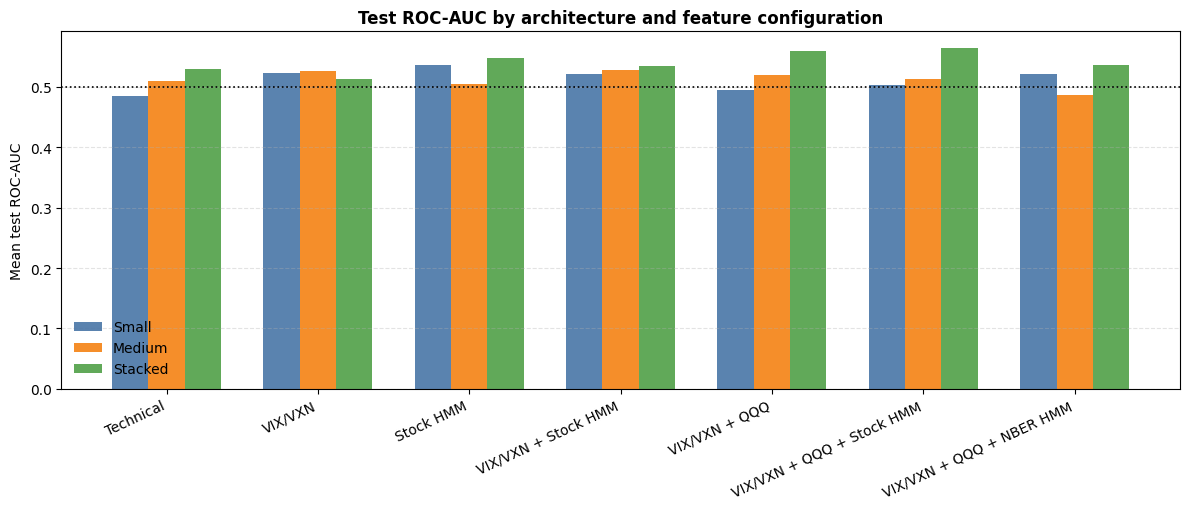

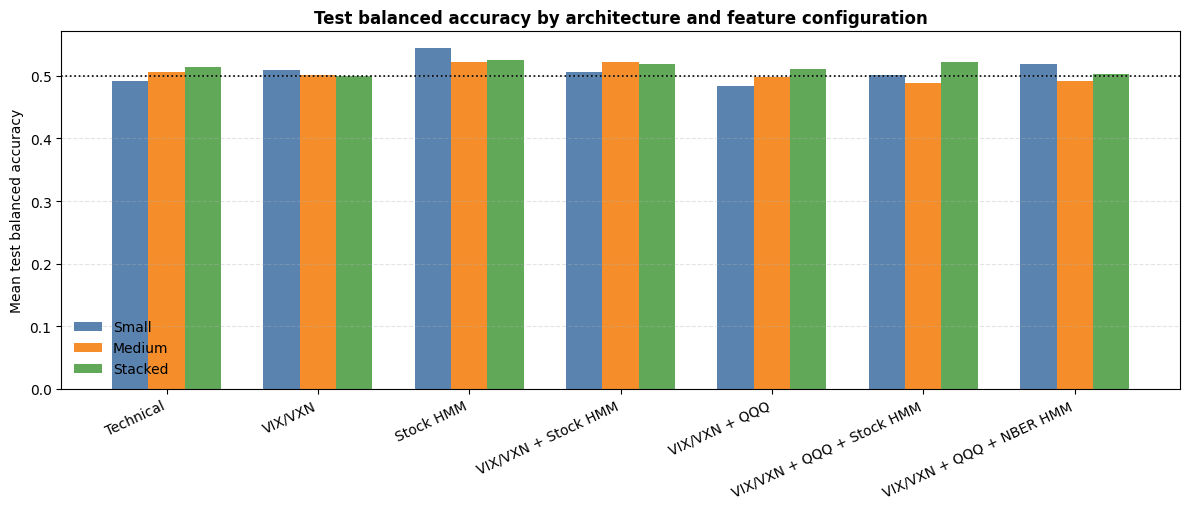

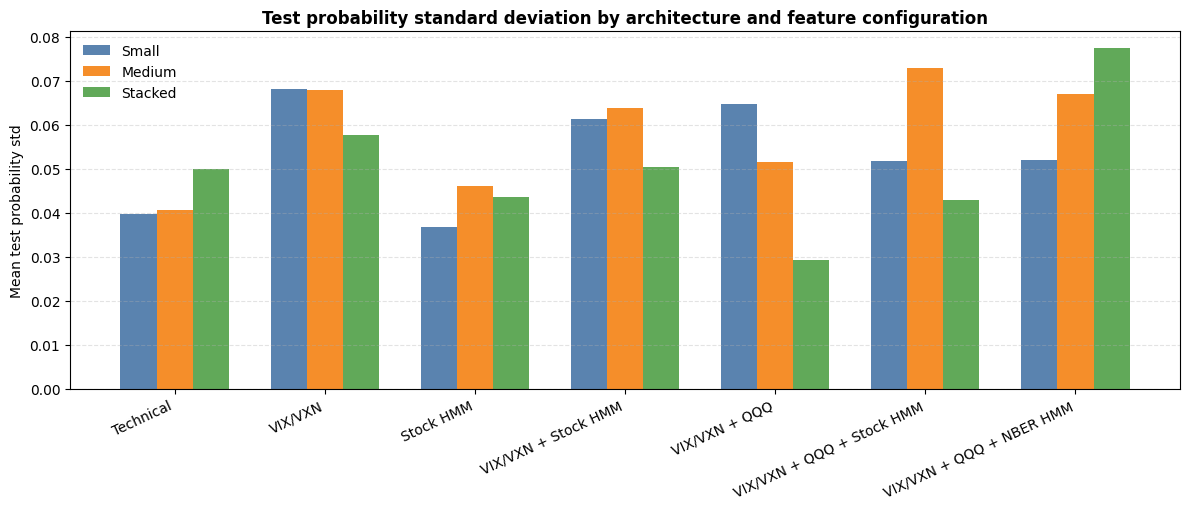

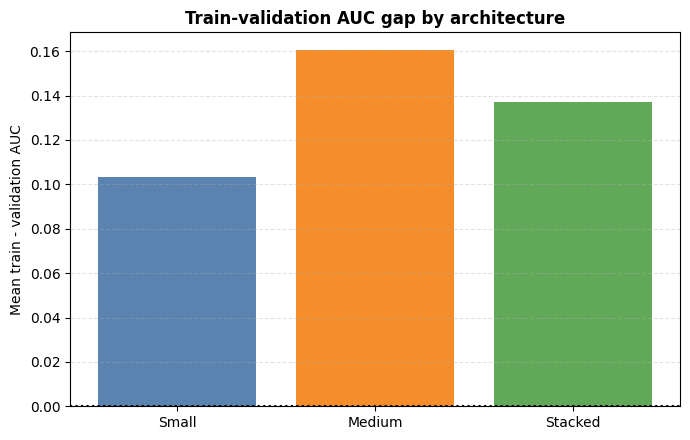

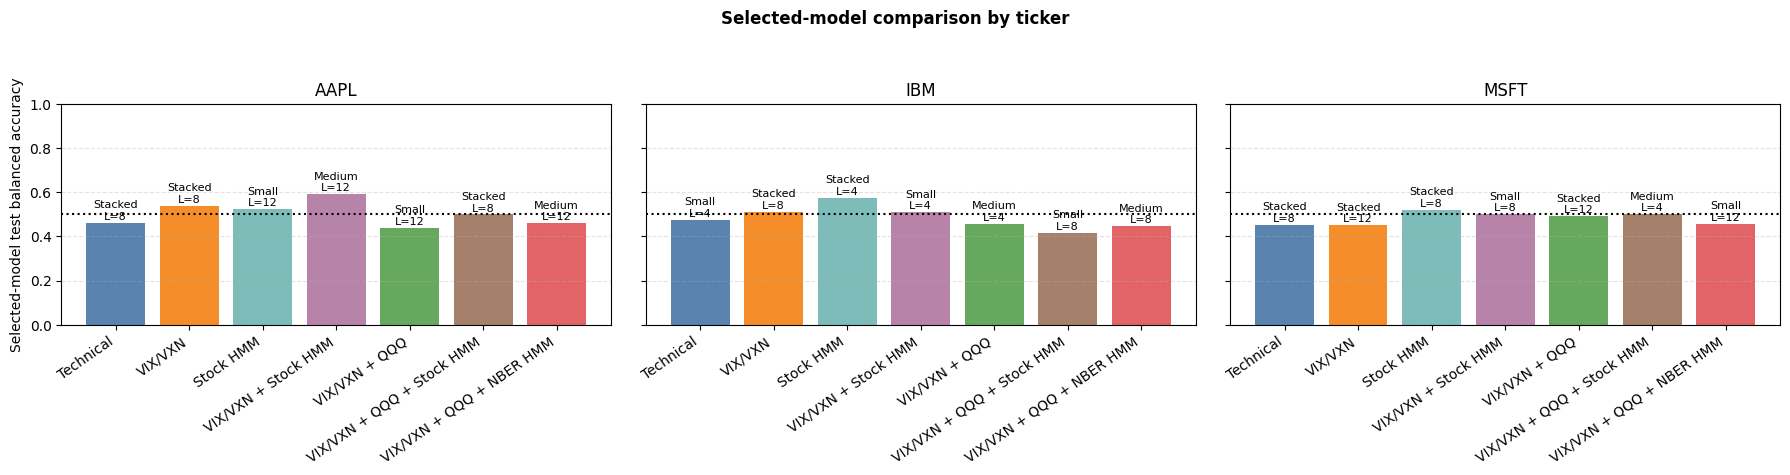

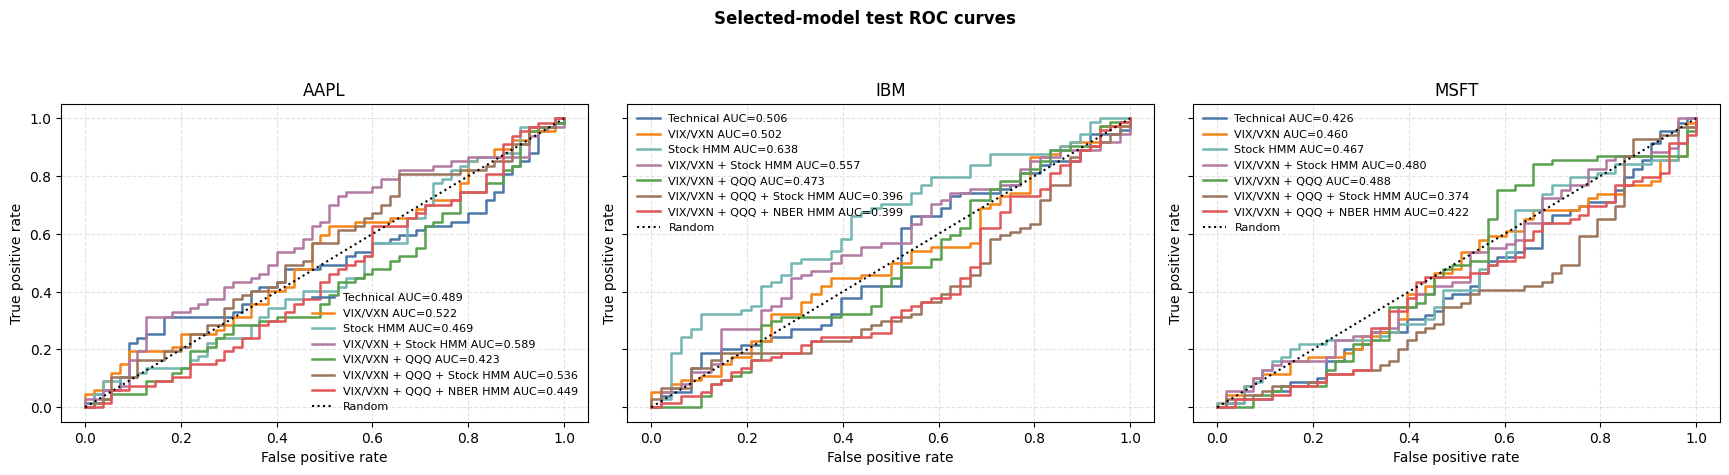

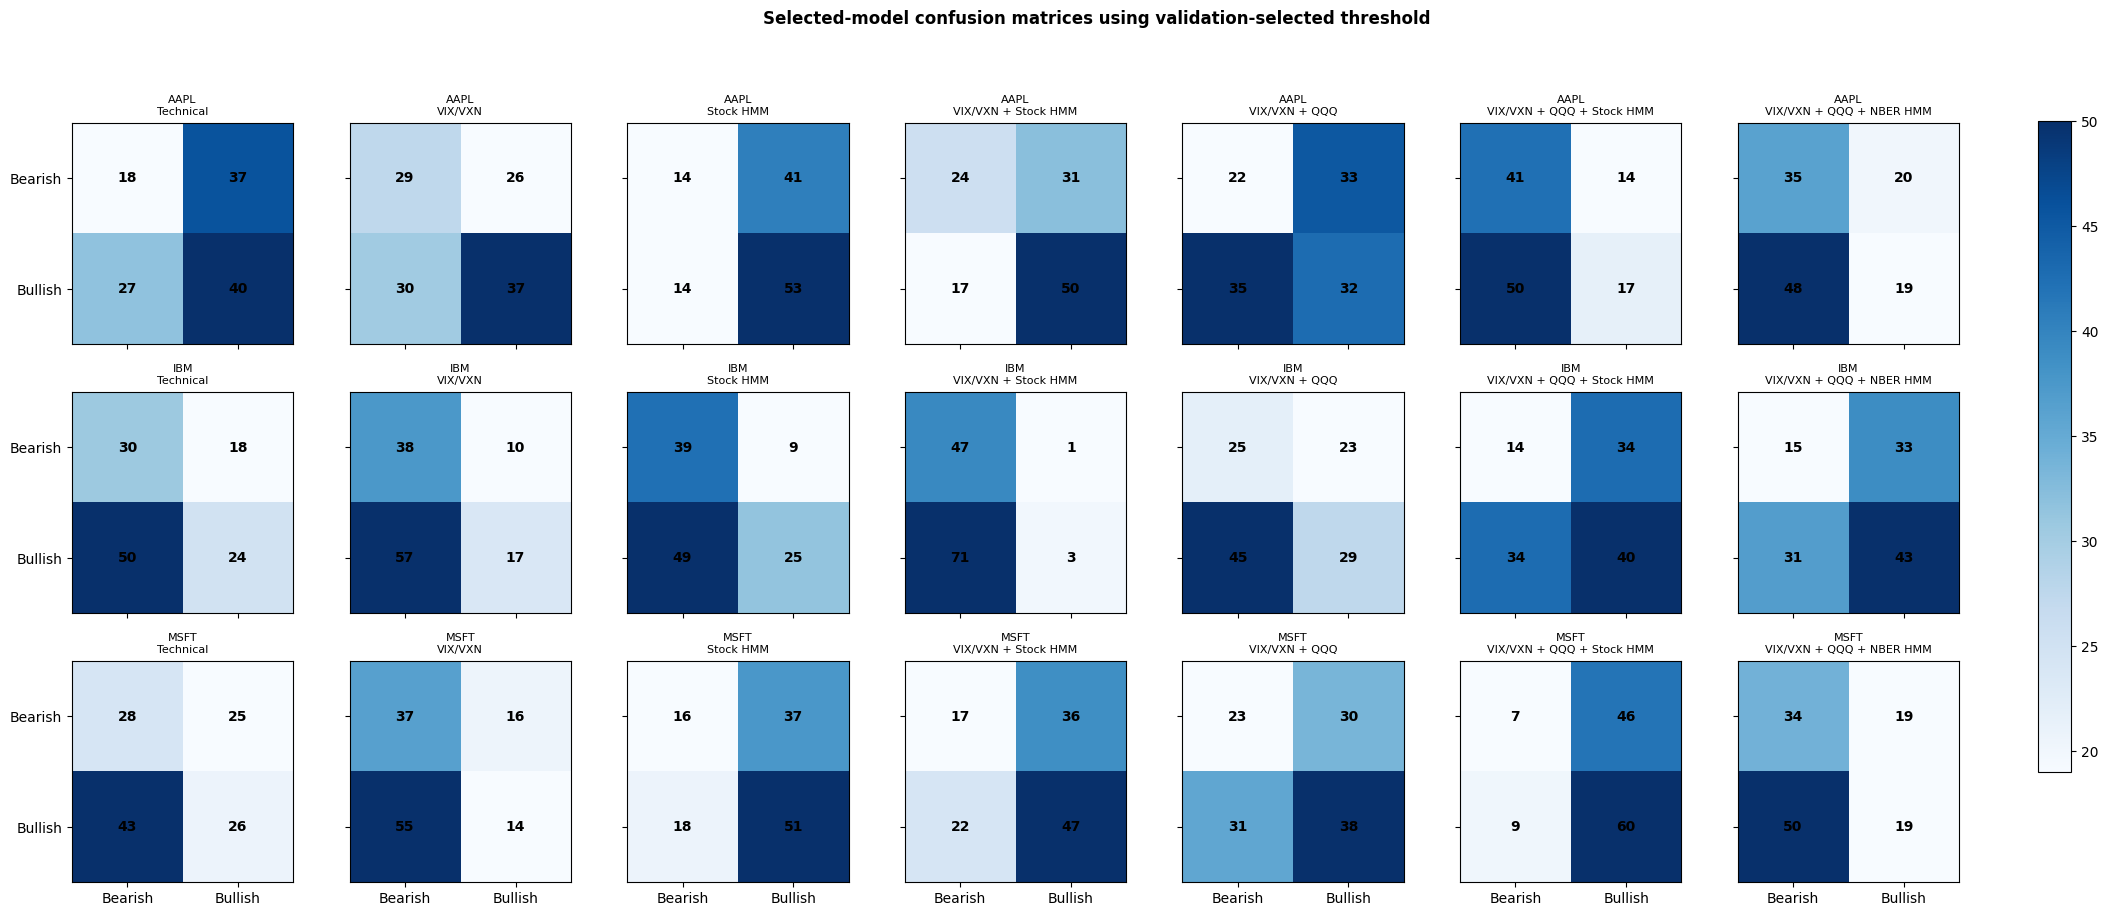

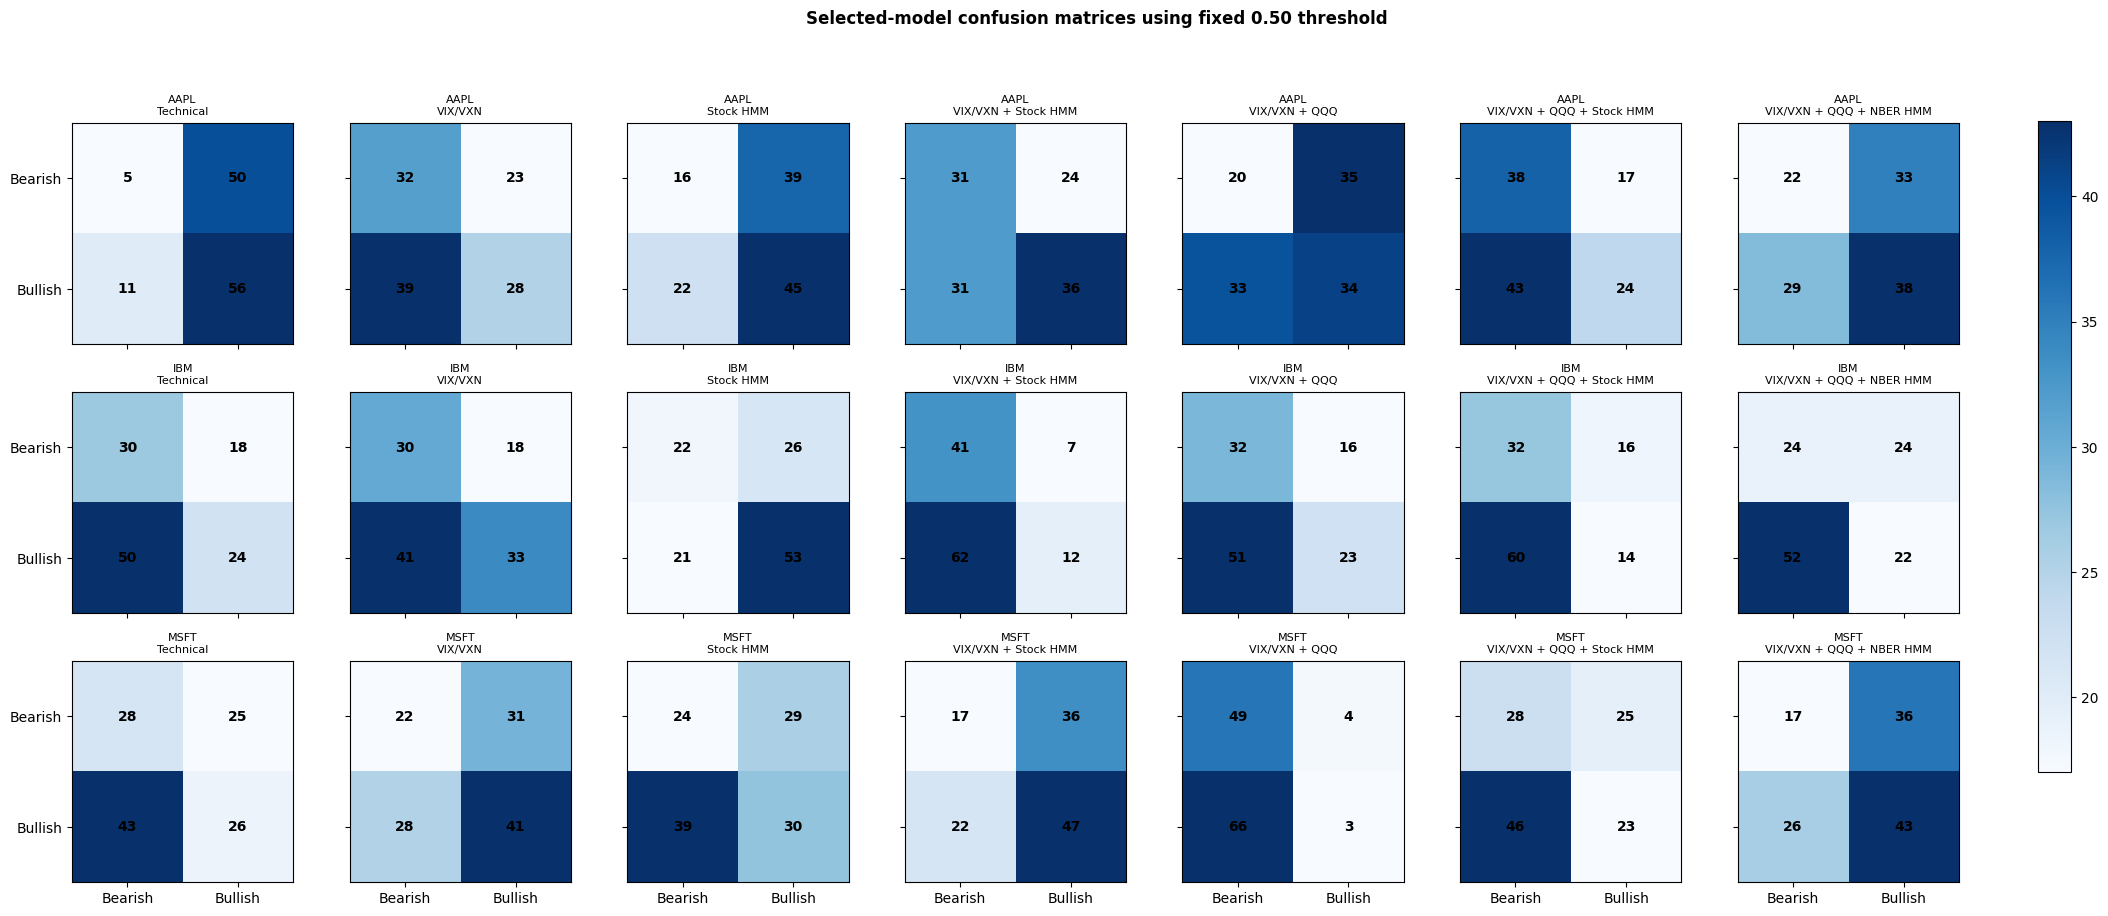

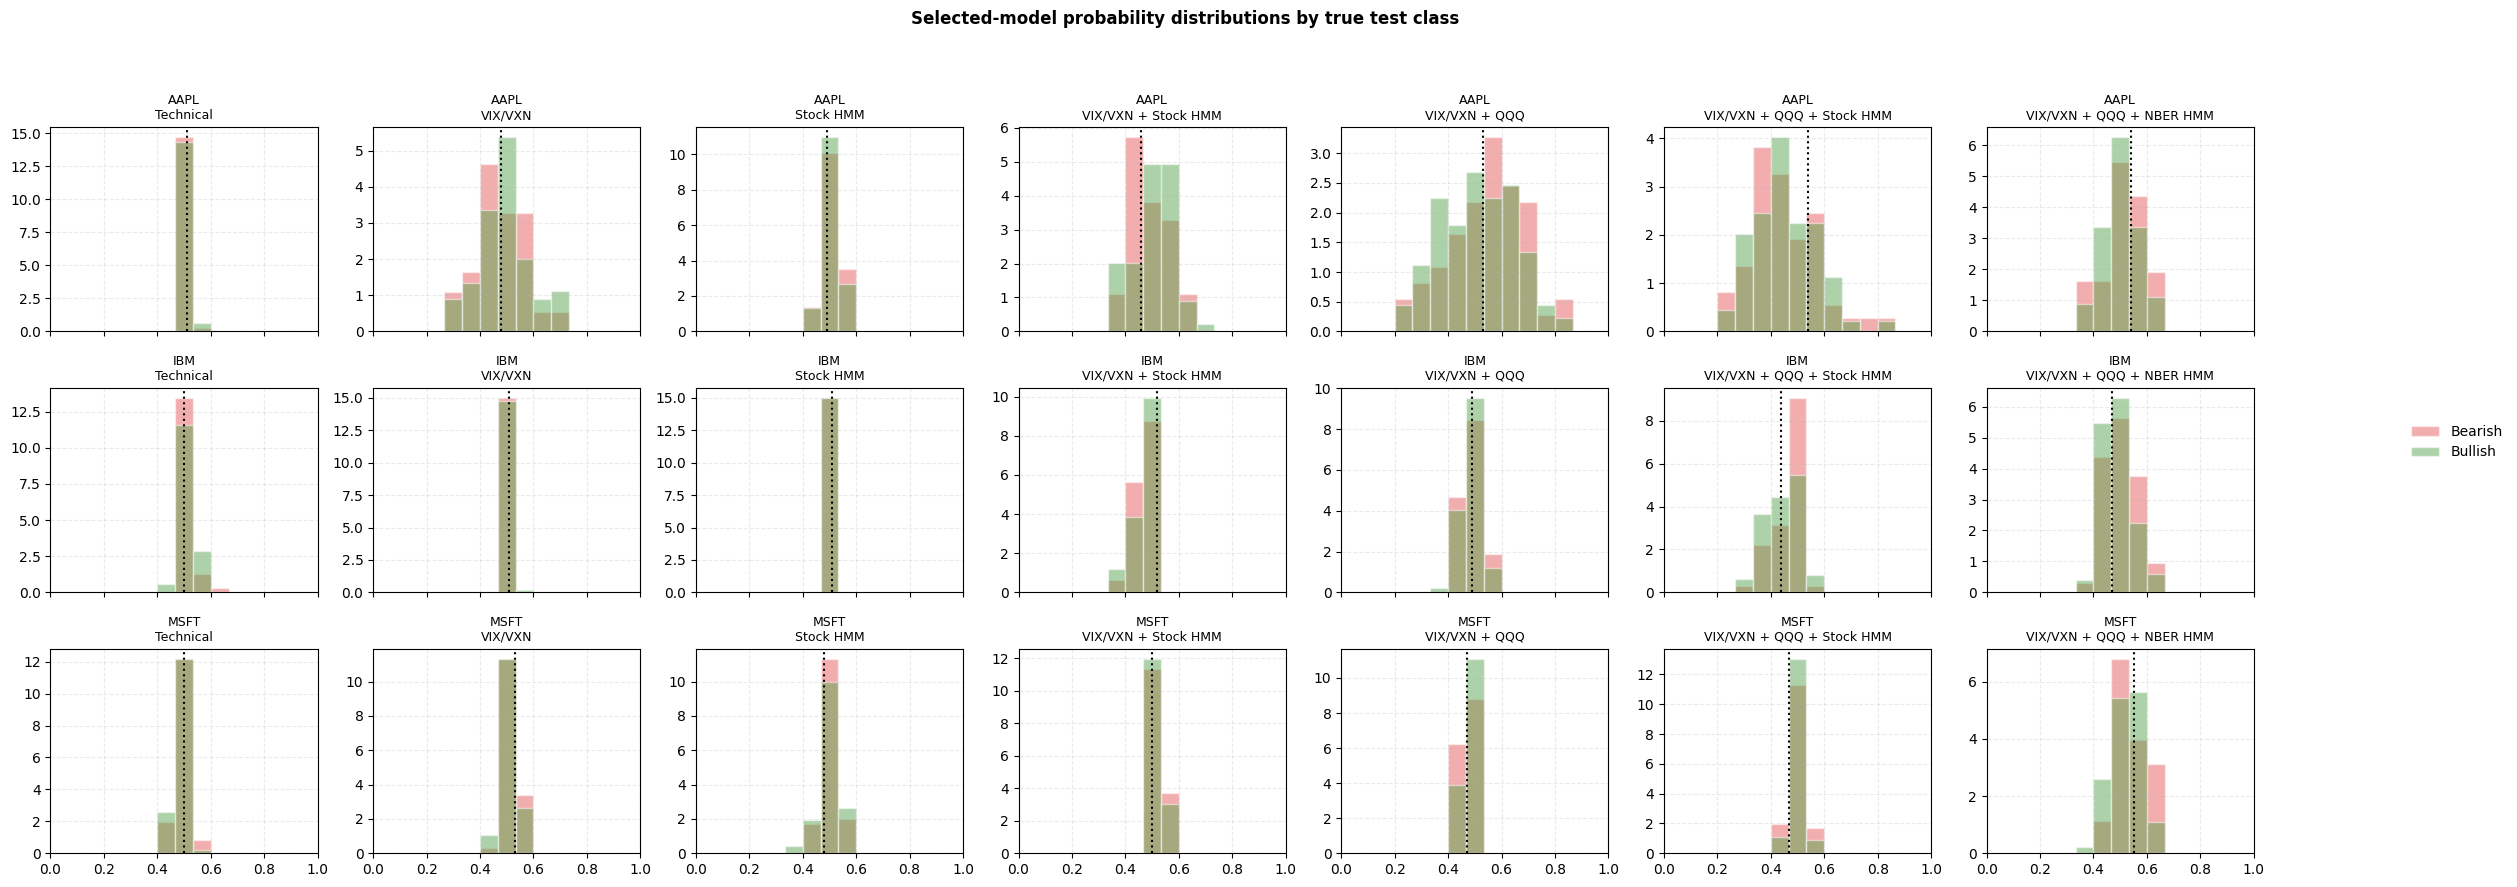

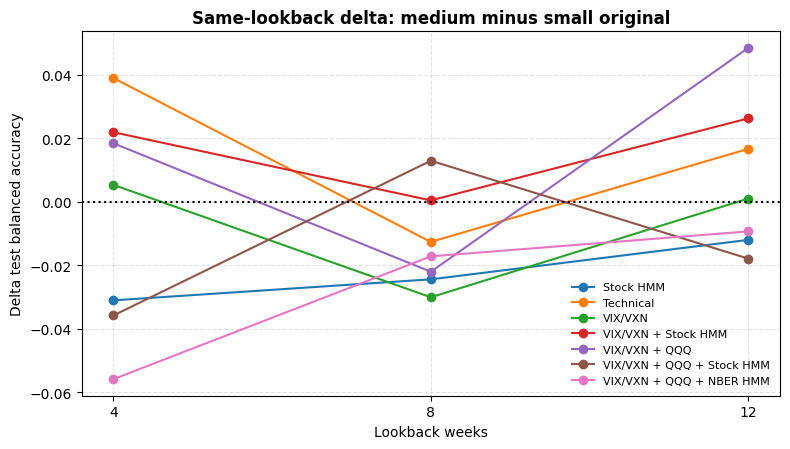

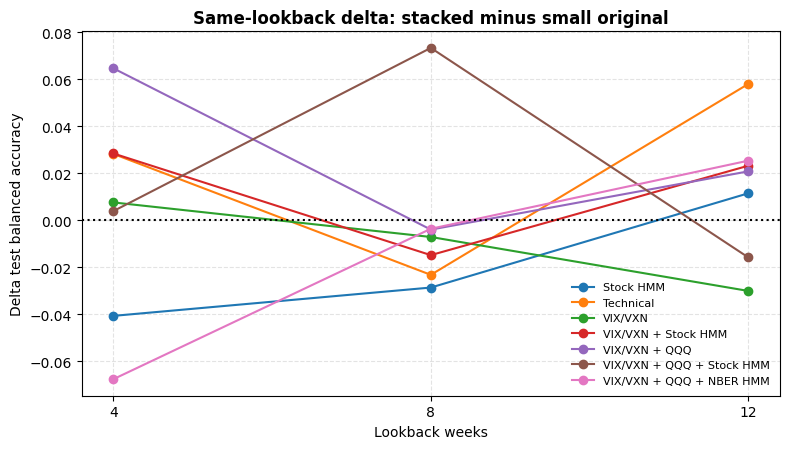

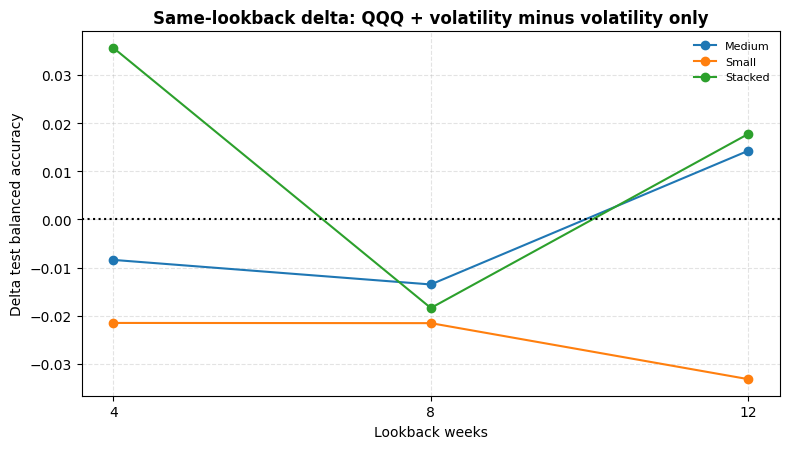

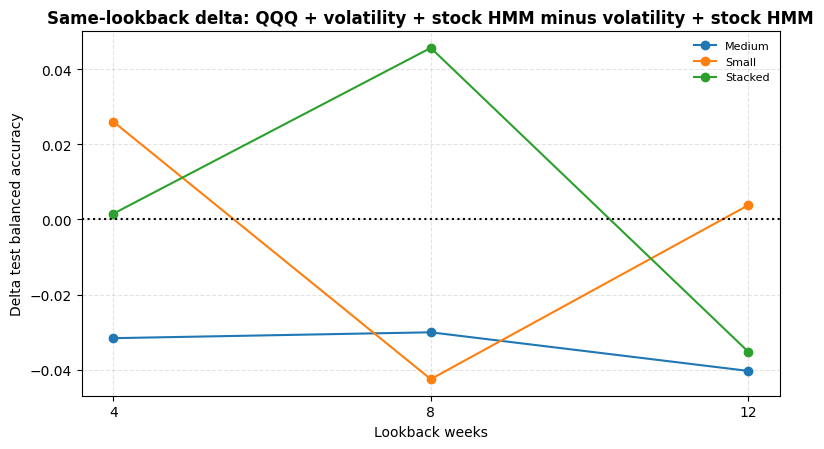

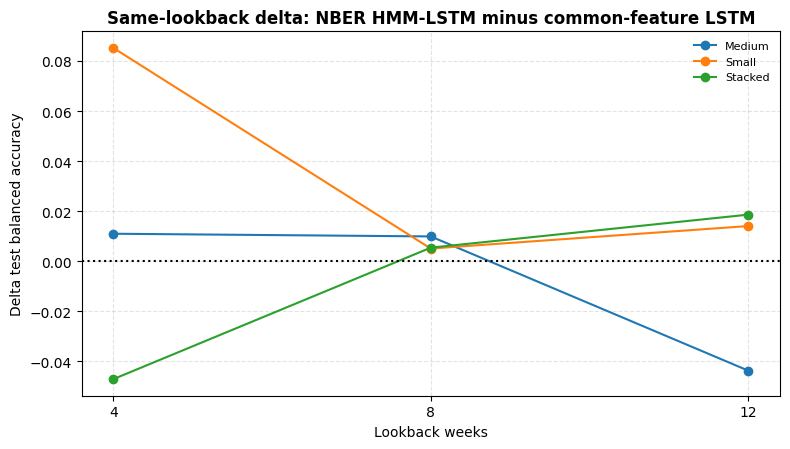

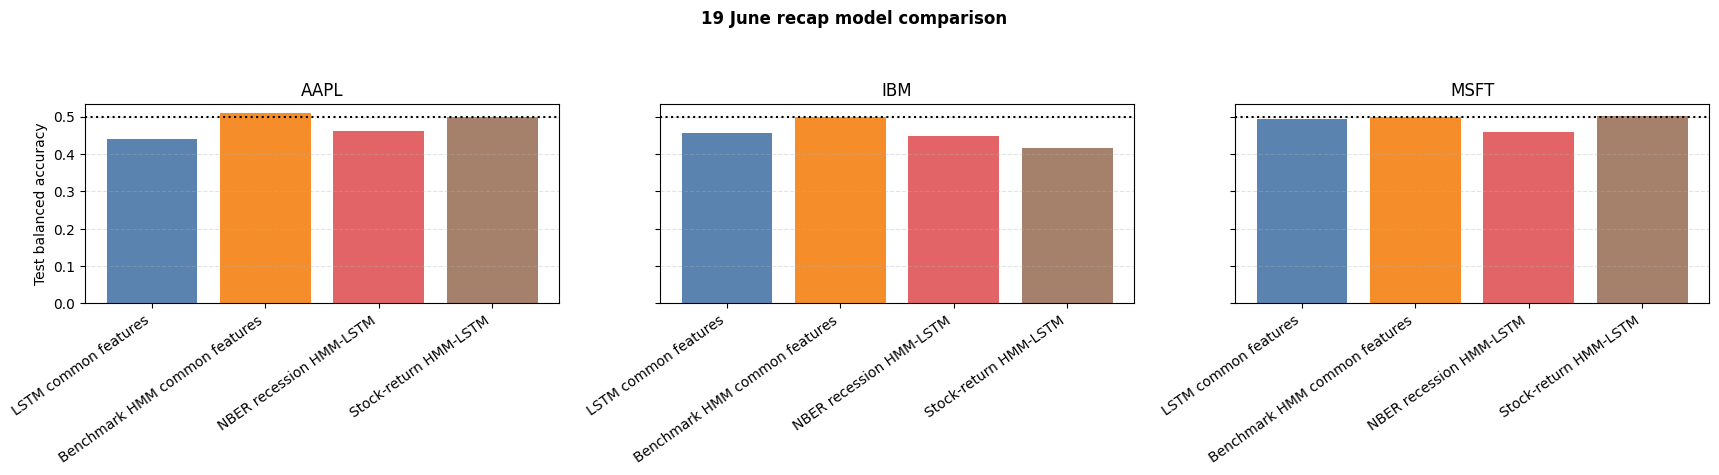

,check,passed
0,Weekly target is unchanged,True
1,Saved stock HMM was not refitted,True
2,Benchmark HMM was fitted on common features,True
3,Recap common feature config exists,True
4,Recession/expansion Markov-chain features were...,True
5,Only next-step HMM probabilities were used,True
6,"Lookbacks are capped at 4, 8, 12",True
7,No leakage columns were used as features,True
8,No backward-fill method was used,True
9,Sequence-continuity checks were performed,True


All final sanity checks passed.
Sanity-check report saved to: d:\BA_year_3\honour project\outputs\weekly_context_lstm_qqq_final\weekly_context_lstm_qqq_final_sanity_checks.csv
Saved plot files:
d:\BA_year_3\honour project\outputs\weekly_context_lstm_qqq_final\plots\test_roc_auc_by_architecture_feature_config.png
d:\BA_year_3\honour project\outputs\weekly_context_lstm_qqq_final\plots\test_balanced_accuracy_by_architecture_feature_config.png
d:\BA_year_3\honour project\outputs\weekly_context_lstm_qqq_final\plots\test_probability_std_by_architecture_feature_config.png
d:\BA_year_3\honour project\outputs\weekly_context_lstm_qqq_final\plots\train_validation_auc_gap_by_architecture.png
d:\BA_year_3\honour project\outputs\weekly_context_lstm_qqq_final\plots\selected_model_comparison_by_ticker.png
d:\BA_year_3\honour project\outputs\weekly_context_lstm_qqq_final\plots\selected_model_roc_curves.png
d:\BA_year_3\honour project\outputs\weekly_context_lstm_qqq_final\plots\selected_model_confusion_

In [7]:
select_cols = ["ticker", "feature_config", "validation_selected_threshold_val_roc_auc", "validation_selected_threshold_val_balanced_accuracy", "validation_selected_threshold_val_f1", "validation_selected_threshold_val_probability_std"]
weekly_context_lstm_qqq_final_selected_models_df = (
    weekly_context_lstm_qqq_final_results_df.sort_values(select_cols, ascending=[True, True, False, False, False, False], na_position="last")
    .groupby(["ticker", "feature_config"], as_index=False).head(1).sort_values(["ticker", "feature_config"]).reset_index(drop=True)
)
weekly_context_lstm_qqq_final_selected_models_df["selection_rule"] = "highest validation ROC-AUC, then validation balanced accuracy, validation F1, and validation probability std"
weekly_context_lstm_qqq_final_selected_models_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_selected_models.csv", index=False)

metric_cols = ["validation_selected_threshold_test_balanced_accuracy", "validation_selected_threshold_test_roc_auc", "validation_selected_threshold_test_f1", "validation_selected_threshold_test_kappa", "validation_selected_threshold_test_probability_std", "validation_selected_threshold_val_balanced_accuracy", "validation_selected_threshold_val_roc_auc", "validation_selected_threshold_val_f1", "train_validation_auc_gap"]
summary_arch = weekly_context_lstm_qqq_final_results_df.groupby("architecture_config")[metric_cols].agg(["mean", "std", "min", "max"]).round(6)
summary_arch.columns = ["_".join(c).strip() for c in summary_arch.columns]
weekly_context_lstm_qqq_final_summary_by_architecture_df = summary_arch.reset_index()
weekly_context_lstm_qqq_final_summary_by_architecture_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_summary_by_architecture.csv", index=False)
summary_feature = weekly_context_lstm_qqq_final_results_df.groupby("feature_config")[metric_cols].agg(["mean", "std", "min", "max"]).round(6)
summary_feature.columns = ["_".join(c).strip() for c in summary_feature.columns]
weekly_context_lstm_qqq_final_summary_by_feature_config_df = summary_feature.reset_index()
weekly_context_lstm_qqq_final_summary_by_feature_config_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_summary_by_feature_config.csv", index=False)

delta_metrics = ["validation_selected_threshold_test_balanced_accuracy", "validation_selected_threshold_test_roc_auc", "validation_selected_threshold_test_f1", "validation_selected_threshold_test_kappa", "validation_selected_threshold_test_probability_std"]
def arch_delta(challenger, baseline, label):
    keys = ["ticker", "lookback", "feature_config"]
    left = weekly_context_lstm_qqq_final_results_df.loc[weekly_context_lstm_qqq_final_results_df["architecture_config"].eq(challenger), keys + delta_metrics]
    right = weekly_context_lstm_qqq_final_results_df.loc[weekly_context_lstm_qqq_final_results_df["architecture_config"].eq(baseline), keys + delta_metrics]
    m = left.merge(right, on=keys, suffixes=("_challenger", "_baseline"), validate="one_to_one")
    m.insert(3, "comparison", label); m.insert(4, "challenger", challenger); m.insert(5, "baseline", baseline)
    for metric in delta_metrics: m[f"delta_{metric}"] = m[f"{metric}_challenger"] - m[f"{metric}_baseline"]
    return m[keys + ["comparison", "challenger", "baseline"] + [f"delta_{x}" for x in delta_metrics]]
def feature_delta(challenger, baseline, label):
    keys = ["ticker", "lookback", "architecture_config"]
    left = weekly_context_lstm_qqq_final_results_df.loc[weekly_context_lstm_qqq_final_results_df["feature_config"].eq(challenger), keys + delta_metrics]
    right = weekly_context_lstm_qqq_final_results_df.loc[weekly_context_lstm_qqq_final_results_df["feature_config"].eq(baseline), keys + delta_metrics]
    m = left.merge(right, on=keys, suffixes=("_challenger", "_baseline"), validate="one_to_one")
    m.insert(3, "comparison", label); m.insert(4, "challenger", challenger); m.insert(5, "baseline", baseline)
    for metric in delta_metrics: m[f"delta_{metric}"] = m[f"{metric}_challenger"] - m[f"{metric}_baseline"]
    return m[keys + ["comparison", "challenger", "baseline"] + [f"delta_{x}" for x in delta_metrics]]
delta_frames = []
if {"medium", "small_original"}.issubset(ACTIVE_ARCHITECTURES): delta_frames.append(arch_delta("medium", "small_original", "medium_minus_small_original"))
if {"stacked", "small_original"}.issubset(ACTIVE_ARCHITECTURES): delta_frames.append(arch_delta("stacked", "small_original", "stacked_minus_small_original"))
delta_frames.append(feature_delta("vol_market_context_qqq", "vol_context_compact", "vol_market_context_qqq_minus_vol_context_compact"))
delta_frames.append(feature_delta("vol_market_context_qqq_hmm", "vol_context_compact_hmm", "vol_market_context_qqq_hmm_minus_vol_context_compact_hmm"))
delta_frames.append(feature_delta("vol_market_context_qqq_recession_hmm", "vol_market_context_qqq", "vol_market_context_qqq_recession_hmm_minus_vol_market_context_qqq"))
weekly_context_lstm_qqq_final_same_lookback_deltas_df = pd.concat(delta_frames, ignore_index=True)
weekly_context_lstm_qqq_final_same_lookback_deltas_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_qqq_final_same_lookback_deltas.csv", index=False)


def selected_lstm_rows_for_recap(feature_config: str, model_label: str) -> pd.DataFrame:
    cols = [
        "ticker", "feature_config", "architecture_config", "lookback",
        "validation_selected_threshold_test_accuracy", "validation_selected_threshold_test_balanced_accuracy",
        "validation_selected_threshold_test_f1", "validation_selected_threshold_test_kappa", "validation_selected_threshold_test_roc_auc",
        "validation_selected_threshold_test_share_predicted_bullish", "validation_selected_threshold_test_share_actual_bullish",
        "validation_selected_threshold_val_balanced_accuracy", "validation_selected_threshold_val_roc_auc",
    ]
    out = weekly_context_lstm_qqq_final_selected_models_df.loc[
        weekly_context_lstm_qqq_final_selected_models_df["feature_config"].eq(feature_config),
        cols,
    ].copy()
    out["model_label"] = model_label
    out = out.rename(
        columns={
            "validation_selected_threshold_test_accuracy": "test_accuracy",
            "validation_selected_threshold_test_balanced_accuracy": "test_balanced_accuracy",
            "validation_selected_threshold_test_f1": "test_f1",
            "validation_selected_threshold_test_kappa": "test_kappa",
            "validation_selected_threshold_test_roc_auc": "test_roc_auc",
            "validation_selected_threshold_test_share_predicted_bullish": "test_share_predicted_bullish",
            "validation_selected_threshold_test_share_actual_bullish": "test_share_actual_bullish",
            "validation_selected_threshold_val_balanced_accuracy": "val_balanced_accuracy",
            "validation_selected_threshold_val_roc_auc": "val_roc_auc",
        }
    )
    return out

benchmark_recap_rows = benchmark_hmm_results_df.copy()
benchmark_recap_rows["model_label"] = "Benchmark HMM common features"
benchmark_recap_rows["architecture_config"] = "hmm"
benchmark_recap_rows["lookback"] = np.nan
benchmark_recap_rows = benchmark_recap_rows.rename(columns={"test_cohen_kappa": "test_kappa", "val_cohen_kappa": "val_kappa"})
benchmark_recap_rows = benchmark_recap_rows[
    [
        "ticker", "feature_config", "architecture_config", "lookback", "model_label",
        "test_accuracy", "test_balanced_accuracy", "test_f1", "test_kappa", "test_roc_auc",
        "test_share_predicted_bullish", "test_share_actual_bullish", "val_balanced_accuracy", "val_roc_auc",
    ]
]
recap_model_comparison_df = pd.concat(
    [
        selected_lstm_rows_for_recap(COMMON_RECAP_FEATURE_CONFIG, "LSTM common features"),
        benchmark_recap_rows,
        selected_lstm_rows_for_recap(RECESSION_HMM_LSTM_FEATURE_CONFIG, "NBER recession HMM-LSTM"),
        selected_lstm_rows_for_recap(STOCK_HMM_LSTM_FEATURE_CONFIG, "Stock-return HMM-LSTM"),
    ],
    ignore_index=True,
).sort_values(["ticker", "model_label"]).reset_index(drop=True)
recap_model_comparison_df.to_csv(OUTPUT_DIR / "recap_1906_model_comparison.csv", index=False)
aapl_recap_focus_df = recap_model_comparison_df.loc[recap_model_comparison_df["ticker"].eq("AAPL")].copy()
aapl_recap_focus_df.to_csv(OUTPUT_DIR / "recap_1906_aapl_focus.csv", index=False)
display(recap_model_comparison_df)
display(aapl_recap_focus_df)

FEATURE_CONFIG_ORDER = list(FEATURE_CONFIGS)
ARCHITECTURE_ORDER = list(ARCHITECTURE_CONFIGS)
FEATURE_LABELS = {
    "technical_only": "Technical",
    "vol_context_compact": "VIX/VXN",
    "hmm_informed": "Stock HMM",
    "vol_context_compact_hmm": "VIX/VXN + Stock HMM",
    "vol_market_context_qqq": "VIX/VXN + QQQ",
    "vol_market_context_qqq_hmm": "VIX/VXN + QQQ + Stock HMM",
    "vol_market_context_qqq_recession_hmm": "VIX/VXN + QQQ + NBER HMM",
}
ARCH_LABELS = {"small_original": "Small", "medium": "Medium", "stacked": "Stacked"}
ARCH_COLORS = {"small_original": "#4C78A8", "medium": "#F58518", "stacked": "#54A24B"}
FEATURE_COLORS = {
    "technical_only": "#4C78A8",
    "vol_context_compact": "#F58518",
    "hmm_informed": "#72B7B2",
    "vol_context_compact_hmm": "#B279A2",
    "vol_market_context_qqq": "#59A14F",
    "vol_market_context_qqq_hmm": "#9D755D",
    "vol_market_context_qqq_recession_hmm": "#E15759",
}
STATE_COLORS = {"Bearish": "#E45756", "Bullish": "#54A24B"}
saved_plot_paths = []
def save_plot(filename):
    path = PLOTS_DIR / filename
    plt.savefig(path, dpi=160, bbox_inches="tight")
    saved_plot_paths.append(path)
    return path
def plot_metric(metric_col, ylabel, title, filename, ref=None):
    grouped = weekly_context_lstm_qqq_final_results_df.groupby(["feature_config", "architecture_config"])[metric_col].mean().reset_index()
    x = np.arange(len(FEATURE_CONFIG_ORDER)); width = 0.24 if len(ARCHITECTURE_ORDER) >= 3 else 0.34
    fig, ax = plt.subplots(figsize=(12, 5.2))
    for i, arch in enumerate(ARCHITECTURE_ORDER):
        values = [float(grouped.loc[(grouped.feature_config.eq(f)) & (grouped.architecture_config.eq(arch)), metric_col].iloc[0]) for f in FEATURE_CONFIG_ORDER]
        ax.bar(x + (i - (len(ARCHITECTURE_ORDER) - 1) / 2) * width, values, width=width, label=ARCH_LABELS[arch], color=ARCH_COLORS[arch], alpha=0.92)
    if ref is not None: ax.axhline(ref, color="black", linestyle=":", linewidth=1.2)
    ax.set_xticks(x); ax.set_xticklabels([FEATURE_LABELS[f] for f in FEATURE_CONFIG_ORDER], rotation=25, ha="right")
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight="bold"); ax.grid(True, axis="y", linestyle="--", alpha=0.35); ax.legend(frameon=False)
    fig.tight_layout(); save_plot(filename); plt.show(); plt.close(fig)
plot_metric("validation_selected_threshold_test_roc_auc", "Mean test ROC-AUC", "Test ROC-AUC by architecture and feature configuration", "test_roc_auc_by_architecture_feature_config.png", 0.5)
plot_metric("validation_selected_threshold_test_balanced_accuracy", "Mean test balanced accuracy", "Test balanced accuracy by architecture and feature configuration", "test_balanced_accuracy_by_architecture_feature_config.png", 0.5)
plot_metric("validation_selected_threshold_test_probability_std", "Mean test probability std", "Test probability standard deviation by architecture and feature configuration", "test_probability_std_by_architecture_feature_config.png")

gap = weekly_context_lstm_qqq_final_results_df.groupby("architecture_config")["train_validation_auc_gap"].mean().reindex(ARCHITECTURE_ORDER)
fig, ax = plt.subplots(figsize=(7, 4.5)); ax.bar(np.arange(len(gap)), gap.values, color=[ARCH_COLORS[a] for a in gap.index], alpha=0.92)
ax.axhline(0, color="black", linestyle=":"); ax.set_xticks(np.arange(len(gap))); ax.set_xticklabels([ARCH_LABELS[a] for a in gap.index])
ax.set_ylabel("Mean train - validation AUC"); ax.set_title("Train-validation AUC gap by architecture", fontweight="bold"); ax.grid(True, axis="y", linestyle="--", alpha=0.35)
fig.tight_layout(); save_plot("train_validation_auc_gap_by_architecture.png"); plt.show(); plt.close(fig)

def selected_test_predictions(threshold_type):
    keys = weekly_context_lstm_qqq_final_selected_models_df[["ticker", "feature_config", "architecture_config", "lookback"]]
    return weekly_context_lstm_qqq_final_predictions_df.loc[(weekly_context_lstm_qqq_final_predictions_df.Split.eq("test")) & (weekly_context_lstm_qqq_final_predictions_df.threshold_type.eq(threshold_type))].merge(keys, left_on=["Ticker", "feature_config", "architecture_config", "lookback"], right_on=["ticker", "feature_config", "architecture_config", "lookback"], how="inner", validate="many_to_one")

fig, axes = plt.subplots(1, len(TICKERS), figsize=(6 * len(TICKERS), 4.8), sharey=True)
if len(TICKERS) == 1: axes = [axes]
for ax, ticker in zip(axes, TICKERS):
    df_t = weekly_context_lstm_qqq_final_selected_models_df.loc[weekly_context_lstm_qqq_final_selected_models_df.ticker.eq(ticker)].copy()
    df_t["feature_config"] = pd.Categorical(df_t["feature_config"], categories=FEATURE_CONFIG_ORDER, ordered=True); df_t = df_t.sort_values("feature_config")
    ax.bar(np.arange(len(df_t)), df_t["validation_selected_threshold_test_balanced_accuracy"], color=[FEATURE_COLORS[f] for f in df_t["feature_config"].astype(str)], alpha=0.92)
    for i, (_, row) in enumerate(df_t.iterrows()): ax.text(i, row["validation_selected_threshold_test_balanced_accuracy"] + 0.015, f"{ARCH_LABELS[row['architecture_config']]}\nL={int(row['lookback'])}", ha="center", fontsize=8)
    ax.axhline(0.5, color="black", linestyle=":"); ax.set_xticks(np.arange(len(df_t))); ax.set_xticklabels([FEATURE_LABELS[f] for f in df_t["feature_config"].astype(str)], rotation=35, ha="right"); ax.set_ylim(0, 1); ax.set_title(ticker); ax.grid(True, axis="y", linestyle="--", alpha=0.35)
axes[0].set_ylabel("Selected-model test balanced accuracy"); fig.suptitle("Selected-model comparison by ticker", fontweight="bold"); fig.tight_layout(rect=[0, 0, 1, 0.93]); save_plot("selected_model_comparison_by_ticker.png"); plt.show(); plt.close(fig)

selected_valtest = selected_test_predictions("validation_selected_threshold")
fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.8 * len(TICKERS), 4.8), sharex=True, sharey=True)
if len(TICKERS) == 1: axes = [axes]
for ax, ticker in zip(axes, TICKERS):
    df_t = selected_valtest.loc[selected_valtest.Ticker.eq(ticker)]
    for feature in FEATURE_CONFIG_ORDER:
        df_f = df_t.loc[df_t.feature_config.eq(feature)]
        if df_f.empty or df_f["Target_State_Binary"].nunique() < 2: continue
        fpr, tpr, _ = roc_curve(df_f["Target_State_Binary"].astype(int), df_f["predicted_bullish_probability"].astype(float))
        auc = roc_auc_score(df_f["Target_State_Binary"].astype(int), df_f["predicted_bullish_probability"].astype(float))
        ax.plot(fpr, tpr, label=f"{FEATURE_LABELS[feature]} AUC={auc:.3f}", color=FEATURE_COLORS[feature], linewidth=1.8)
    ax.plot([0, 1], [0, 1], color="black", linestyle=":", label="Random"); ax.set_title(ticker); ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate"); ax.grid(True, linestyle="--", alpha=0.35); ax.legend(fontsize=8, frameon=False)
fig.suptitle("Selected-model test ROC curves", fontweight="bold"); fig.tight_layout(rect=[0, 0, 1, 0.93]); save_plot("selected_model_roc_curves.png"); plt.show(); plt.close(fig)

def plot_conf(threshold_type, filename, title):
    df = selected_test_predictions(threshold_type); n_rows, n_cols = len(TICKERS), len(FEATURE_CONFIG_ORDER)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.1 * n_rows), sharex=True, sharey=True)
    if n_rows == 1: axes = np.asarray([axes])
    if n_cols == 1: axes = axes.reshape(n_rows, 1)
    last = None
    for i, ticker in enumerate(TICKERS):
        for j, feature in enumerate(FEATURE_CONFIG_ORDER):
            ax = axes[i, j]; df_f = df.loc[(df.Ticker.eq(ticker)) & (df.feature_config.eq(feature))]
            if df_f.empty: ax.set_visible(False); continue
            cm = confusion_matrix(df_f["Target_State_Binary"], df_f["predicted_state_binary"], labels=[0, 1]); last = ax.imshow(cm, cmap="Blues")
            for r in range(2):
                for c in range(2): ax.text(c, r, str(cm[r, c]), ha="center", va="center", fontweight="bold")
            ax.set_title(f"{ticker}\n{FEATURE_LABELS[feature]}", fontsize=8); ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.set_xticklabels(["Bearish", "Bullish"]); ax.set_yticklabels(["Bearish", "Bullish"])
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 0.90, 0.94])
    if last is not None:
        cbar_ax = fig.add_axes([0.92, 0.16, 0.015, 0.70])
        fig.colorbar(last, cax=cbar_ax)
    save_plot(filename); plt.show(); plt.close(fig)
plot_conf("validation_selected_threshold", "selected_model_confusion_matrices_validation_selected_threshold.png", "Selected-model confusion matrices using validation-selected threshold")
plot_conf("fixed_threshold_0_50", "selected_model_confusion_matrices_fixed_threshold_0_50.png", "Selected-model confusion matrices using fixed 0.50 threshold")

selected_valtest = selected_valtest.copy(); selected_valtest["actual_state"] = np.where(selected_valtest["Target_State_Binary"].eq(1), "Bullish", "Bearish")
fig, axes = plt.subplots(len(TICKERS), len(FEATURE_CONFIG_ORDER), figsize=(3.4 * len(FEATURE_CONFIG_ORDER), 3.0 * len(TICKERS)), sharex=True)
if len(TICKERS) == 1: axes = np.asarray([axes])
bins = np.linspace(0, 1, 16)
for i, ticker in enumerate(TICKERS):
    for j, feature in enumerate(FEATURE_CONFIG_ORDER):
        ax = axes[i, j]; df_f = selected_valtest.loc[(selected_valtest.Ticker.eq(ticker)) & (selected_valtest.feature_config.eq(feature))]
        if df_f.empty: ax.set_visible(False); continue
        for state in ["Bearish", "Bullish"]:
            ax.hist(df_f.loc[df_f.actual_state.eq(state), "predicted_bullish_probability"], bins=bins, alpha=0.48, density=True, label=state, color=STATE_COLORS[state], edgecolor="white")
        ax.axvline(float(df_f["decision_threshold"].iloc[0]), color="black", linestyle=":"); ax.set_xlim(0, 1); ax.set_title(f"{ticker}\n{FEATURE_LABELS[feature]}", fontsize=9); ax.grid(True, linestyle="--", alpha=0.25)
handles, labels = axes[0, 0].get_legend_handles_labels(); fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("Selected-model probability distributions by true test class", fontweight="bold"); fig.tight_layout(rect=[0, 0, 0.96, 0.94]); save_plot("selected_model_probability_distributions_by_true_class.png"); plt.show(); plt.close(fig)

FEATURE_DELTA_COMPARISONS = {
    "vol_market_context_qqq_minus_vol_context_compact",
    "vol_market_context_qqq_hmm_minus_vol_context_compact_hmm",
    "vol_market_context_qqq_recession_hmm_minus_vol_market_context_qqq",
}

def plot_delta(comparison, filename, title):
    col = "delta_validation_selected_threshold_test_balanced_accuracy"
    df = weekly_context_lstm_qqq_final_same_lookback_deltas_df.loc[weekly_context_lstm_qqq_final_same_lookback_deltas_df.comparison.eq(comparison)].copy()
    fig, ax = plt.subplots(figsize=(8, 4.6))
    group_col = "architecture_config" if comparison in FEATURE_DELTA_COMPARISONS else "feature_config"
    labels = ARCH_LABELS if group_col == "architecture_config" else FEATURE_LABELS
    for name, group in df.dropna(subset=[group_col]).groupby(group_col):
        g = group.groupby("lookback", as_index=False)[col].mean().sort_values("lookback")
        ax.plot(g.lookback, g[col], marker="o", label=labels.get(name, name))
    ax.axhline(0, color="black", linestyle=":"); ax.set_xticks(ACTIVE_LOOKBACKS); ax.set_xlabel("Lookback weeks"); ax.set_ylabel("Delta test balanced accuracy"); ax.set_title(title, fontweight="bold"); ax.grid(True, linestyle="--", alpha=0.35); ax.legend(fontsize=8, frameon=False)
    fig.tight_layout(); save_plot(filename); plt.show(); plt.close(fig)
plot_delta("medium_minus_small_original", "delta_medium_minus_small_original.png", "Same-lookback delta: medium minus small original")
plot_delta("stacked_minus_small_original", "delta_stacked_minus_small_original.png", "Same-lookback delta: stacked minus small original")
plot_delta("vol_market_context_qqq_minus_vol_context_compact", "delta_vol_market_context_qqq_minus_vol_context_compact.png", "Same-lookback delta: QQQ + volatility minus volatility only")
plot_delta("vol_market_context_qqq_hmm_minus_vol_context_compact_hmm", "delta_vol_market_context_qqq_hmm_minus_vol_context_compact_hmm.png", "Same-lookback delta: QQQ + volatility + stock HMM minus volatility + stock HMM")
plot_delta("vol_market_context_qqq_recession_hmm_minus_vol_market_context_qqq", "delta_vol_market_context_qqq_recession_hmm_minus_vol_market_context_qqq.png", "Same-lookback delta: NBER HMM-LSTM minus common-feature LSTM")

recap_plot_df = recap_model_comparison_df.copy()
recap_model_order = ["LSTM common features", "Benchmark HMM common features", "NBER recession HMM-LSTM", "Stock-return HMM-LSTM"]
recap_colors = {
    "LSTM common features": "#4C78A8",
    "Benchmark HMM common features": "#F58518",
    "NBER recession HMM-LSTM": "#E15759",
    "Stock-return HMM-LSTM": "#9D755D",
}
fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.8 * len(TICKERS), 4.8), sharey=True)
if len(TICKERS) == 1: axes = [axes]
for ax, ticker in zip(axes, TICKERS):
    df_t = recap_plot_df.loc[recap_plot_df["ticker"].eq(ticker)].copy()
    df_t["model_label"] = pd.Categorical(df_t["model_label"], categories=recap_model_order, ordered=True)
    df_t = df_t.sort_values("model_label")
    ax.bar(np.arange(len(df_t)), df_t["test_balanced_accuracy"], color=[recap_colors[str(m)] for m in df_t["model_label"]], alpha=0.92)
    ax.axhline(0.5, color="black", linestyle=":")
    ax.set_xticks(np.arange(len(df_t)))
    ax.set_xticklabels([str(m) for m in df_t["model_label"]], rotation=35, ha="right")
    ax.set_title(ticker)
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
axes[0].set_ylabel("Test balanced accuracy")
fig.suptitle("19 June recap model comparison", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
save_plot("recap_1906_model_comparison_by_ticker.png"); plt.show(); plt.close(fig)

required_output_files = [
    OUTPUT_DIR / "weekly_context_lstm_qqq_final_results.csv", OUTPUT_DIR / "weekly_context_lstm_qqq_final_predictions.csv",
    OUTPUT_DIR / "weekly_context_lstm_qqq_final_training_history.csv", OUTPUT_DIR / "weekly_context_lstm_qqq_final_selected_models.csv",
    OUTPUT_DIR / "weekly_context_lstm_qqq_final_summary_by_architecture.csv", OUTPUT_DIR / "weekly_context_lstm_qqq_final_summary_by_feature_config.csv",
    OUTPUT_DIR / "weekly_context_lstm_qqq_final_same_lookback_deltas.csv", OUTPUT_DIR / "sequence_continuity_summary.csv",
    OUTPUT_DIR / "nber_recession_expansion_markov_metadata.csv",
    OUTPUT_DIR / "weekly_context_lstm_qqq_final_benchmark_hmm_results.csv", OUTPUT_DIR / "weekly_context_lstm_qqq_final_benchmark_hmm_predictions.csv",
    OUTPUT_DIR / "weekly_context_lstm_qqq_final_benchmark_hmm_threshold_search.csv", OUTPUT_DIR / "weekly_context_lstm_qqq_final_benchmark_hmm_state_summary.csv",
    OUTPUT_DIR / "recap_1906_model_comparison.csv", OUTPUT_DIR / "recap_1906_aapl_focus.csv",
]
required_plot_files = [
    PLOTS_DIR / "test_roc_auc_by_architecture_feature_config.png", PLOTS_DIR / "test_balanced_accuracy_by_architecture_feature_config.png",
    PLOTS_DIR / "test_probability_std_by_architecture_feature_config.png", PLOTS_DIR / "train_validation_auc_gap_by_architecture.png",
    PLOTS_DIR / "selected_model_comparison_by_ticker.png", PLOTS_DIR / "selected_model_roc_curves.png",
    PLOTS_DIR / "selected_model_confusion_matrices_validation_selected_threshold.png", PLOTS_DIR / "selected_model_confusion_matrices_fixed_threshold_0_50.png",
    PLOTS_DIR / "selected_model_probability_distributions_by_true_class.png", PLOTS_DIR / "delta_medium_minus_small_original.png",
    PLOTS_DIR / "delta_stacked_minus_small_original.png", PLOTS_DIR / "delta_vol_market_context_qqq_minus_vol_context_compact.png",
    PLOTS_DIR / "delta_vol_market_context_qqq_hmm_minus_vol_context_compact_hmm.png",
    PLOTS_DIR / "delta_vol_market_context_qqq_recession_hmm_minus_vol_market_context_qqq.png",
    PLOTS_DIR / "recap_1906_model_comparison_by_ticker.png",
]
actual_counts = weekly_context_lstm_qqq_final_results_df.groupby("feature_config")["n_features"].nunique().to_dict()
required_delta_comparisons = {"medium_minus_small_original", "stacked_minus_small_original", "vol_market_context_qqq_minus_vol_context_compact", "vol_market_context_qqq_hmm_minus_vol_context_compact_hmm", "vol_market_context_qqq_recession_hmm_minus_vol_market_context_qqq"}.intersection(set(weekly_context_lstm_qqq_final_same_lookback_deltas_df["comparison"]))
sanity_checks = {
    "Weekly target is unchanged": WEEKLY_TARGET_UNCHANGED and TARGET_COL == "Target_State_Binary",
    "Saved stock HMM was not refitted": not HMM_REFITTED_IN_THIS_NOTEBOOK,
    "Benchmark HMM was fitted on common features": BENCHMARK_HMM_FITTED_IN_THIS_NOTEBOOK and not benchmark_hmm_results_df.empty,
    "Recap common feature config exists": COMMON_RECAP_FEATURE_CONFIG in FEATURE_CONFIGS and FEATURE_CONFIGS[COMMON_RECAP_FEATURE_CONFIG] == RECAP_COMMON_FEATURES,
    "Recession/expansion Markov-chain features were used": RECESSION_EXPANSION_MARKOV_CHAIN_USED and set(NBER_HMM_FEATURES).issubset(model_df.columns),
    "Only next-step HMM probabilities were used": all(c in STOCK_HMM_FEATURES for cols in FEATURE_CONFIGS.values() for c in cols if c.startswith("HMM_")) and all(c in NBER_HMM_FEATURES for cols in FEATURE_CONFIGS.values() for c in cols if c.startswith("NBER_")),
    "Lookbacks are capped at 4, 8, 12": LOOKBACK_GRID == [4, 8, 12],
    "No leakage columns were used as features": not any(set(cols).intersection(LEAKAGE_COLUMNS) for cols in FEATURE_CONFIGS.values()),
    "No backward-fill method was used": not BACKWARD_FILL_METHOD_USED,
    "Sequence-continuity checks were performed": SEQUENCE_CONTINUITY_CHECKS_PERFORMED and sequence_continuity_summary_path.exists(),
    "Validation-selected thresholds used validation data only": VALIDATION_THRESHOLDS_USED_VALIDATION_ONLY and "best_val_threshold_balanced_accuracy" in weekly_context_lstm_qqq_final_results_df.columns,
    "Test data was never used for model selection": (not TEST_DATA_USED_FOR_MODEL_SELECTION) and weekly_context_lstm_qqq_final_selected_models_df["selection_rule"].str.contains("validation", case=False).all(),
    "Both threshold types were evaluated": BOTH_THRESHOLD_TYPES_EVALUATED and set(weekly_context_lstm_qqq_final_predictions_df["threshold_type"]) == {"fixed_threshold_0_50", "validation_selected_threshold"},
    "All expected final training runs were trained": len(weekly_context_lstm_qqq_final_results_df) == EXPECTED_TRAINING_RUNS,
    "Feature counts match expectations": all(actual_counts.get(name) == 1 and int(weekly_context_lstm_qqq_final_results_df.loc[weekly_context_lstm_qqq_final_results_df.feature_config.eq(name), "n_features"].iloc[0]) == EXPECTED_FEATURE_COUNTS[name] for name in FEATURE_CONFIGS),
    "Binary crossentropy was used for main loss": weekly_context_lstm_qqq_final_results_df["loss"].eq(LOSS_FUNCTION).all() and not USE_FOCAL_LOSS,
    "Required same-lookback deltas exist": len(required_delta_comparisons) == (5 if "stacked" in ACTIVE_ARCHITECTURES else 4),
    "All expected output files exist": all(p.exists() for p in required_output_files),
    "All expected plots exist": all(p.exists() for p in required_plot_files),
}
sanity_df = pd.DataFrame([{"check": k, "passed": bool(v)} for k, v in sanity_checks.items()])
sanity_path = OUTPUT_DIR / "weekly_context_lstm_qqq_final_sanity_checks.csv"
sanity_df.to_csv(sanity_path, index=False)
display(sanity_df)
if not sanity_df["passed"].all():
    raise AssertionError(f"Final sanity checks failed: {sanity_df.loc[~sanity_df.passed, 'check'].tolist()}")
print("All final sanity checks passed.")
print(f"Sanity-check report saved to: {sanity_path}")
print("Saved plot files:")
for p in saved_plot_paths:
    print(p)

In [16]:
# Robust Plotly ROC curves from saved QQQ-context CSV outputs only.
# This cell does not train models and does not save figures.
# It installs Plotly into the CURRENT notebook kernel if Plotly is missing.

from pathlib import Path
import importlib.util
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    if importlib.util.find_spec(import_name) is None:
        package = pip_name or import_name
        print(f"Installing {package} into this notebook kernel:")
        print(sys.executable)
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])


ensure_package("plotly")
ensure_package("nbformat")

import pandas as pd
import plotly.graph_objects as go
from IPython.display import HTML, display
from sklearn.metrics import roc_curve, roc_auc_score

RUN_NAME = "weekly_context_lstm_qqq"
TICKERS_TO_PLOT = ["AAPL", "IBM", "MSFT"]

# VS Code sometimes shows a blank output area for Plotly HTML.
# Use browser mode by default because it is the most reliable.
# Options: "browser", "vscode", or "inline_html".
DISPLAY_MODE = "browser"


def show_plotly_html(fig) -> None:
    if DISPLAY_MODE == "browser":
        fig.show(renderer="browser")
        return

    if DISPLAY_MODE == "vscode":
        fig.show(renderer="vscode")
        return

    display(
        HTML(
            fig.to_html(
                full_html=False,
                include_plotlyjs=True,
                default_width="900px",
                default_height="580px",
                config={"displaylogo": False, "responsive": True},
            )
        )
    )


def find_project_root(run_name: str) -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "outputs" / run_name).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find outputs/{run_name}. Current working directory is: {Path.cwd()}"
    )


PROJECT_ROOT = find_project_root(RUN_NAME)
OUTPUT_DIR = PROJECT_ROOT / "outputs" / RUN_NAME

predictions_path = OUTPUT_DIR / f"{RUN_NAME}_predictions.csv"
selected_models_path = OUTPUT_DIR / f"{RUN_NAME}_selected_models.csv"

predictions_df = pd.read_csv(predictions_path)
selected_models_df = pd.read_csv(selected_models_path).rename(columns={"ticker": "Ticker"})

print("Python executable:", sys.executable)
print(f"Loaded predictions: {predictions_path}")
print(f"Loaded selected models: {selected_models_path}")
print("Predictions shape:", predictions_df.shape)
print("Selected models shape:", selected_models_df.shape)

required_prediction_cols = {
    "Ticker",
    "Split",
    "Target_State_Binary",
    "feature_config",
    "lookback",
    "predicted_bullish_probability",
}
missing_prediction_cols = sorted(required_prediction_cols - set(predictions_df.columns))
if missing_prediction_cols:
    raise KeyError(f"Missing prediction columns: {missing_prediction_cols}")

required_selected_cols = {"Ticker", "feature_config", "lookback"}
missing_selected_cols = sorted(required_selected_cols - set(selected_models_df.columns))
if missing_selected_cols:
    raise KeyError(f"Missing selected-model columns: {missing_selected_cols}")

test_predictions = predictions_df[
    predictions_df["Split"].astype(str).str.lower().eq("test")
].copy()

merge_keys = ["Ticker", "feature_config", "lookback"]
selected_keys = selected_models_df[merge_keys].drop_duplicates()
selected_test_df = test_predictions.merge(selected_keys, on=merge_keys, how="inner")

print("Selected test predictions shape:", selected_test_df.shape)
print("Rows by ticker:", selected_test_df.groupby("Ticker").size().to_dict())
if selected_test_df.empty:
    raise ValueError("No selected test predictions found after merging saved CSV outputs.")

label_map = {
    "technical_only": "Technical",
    "hmm_informed": "HMM",
    "vol_context_compact": "Vol compact",
    "vol_context_compact_hmm": "Vol compact + HMM",
    "vol_context_full": "Vol full",
    "vol_context_full_hmm": "Vol full + HMM",
    "market_context_qqq": "Market + QQQ",
    "vol_market_context_qqq": "Vol + market + QQQ",
    "vol_market_context_qqq_hmm": "Vol + market + QQQ + HMM",
}

preferred_order = list(label_map)
present_configs = selected_test_df["feature_config"].dropna().astype(str).unique().tolist()
config_order = [c for c in preferred_order if c in present_configs]
config_order += sorted(c for c in present_configs if c not in config_order)

colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]
color_map = {config: colors[i % len(colors)] for i, config in enumerate(config_order)}

for ticker in TICKERS_TO_PLOT:
    df_t = selected_test_df[selected_test_df["Ticker"].eq(ticker)].copy()

    if df_t.empty:
        print(f"Skipping {ticker}: no selected test rows found.")
        continue

    fig = go.Figure()
    traces_added = 0

    for config_name in config_order:
        df_tc = df_t[df_t["feature_config"].eq(config_name)].copy()
        if df_tc.empty:
            continue

        if df_tc["Target_State_Binary"].nunique() < 2:
            print(f"Skipping {ticker} / {config_name}: test target has fewer than two classes.")
            continue

        y_true = df_tc["Target_State_Binary"].astype(int)
        y_prob = df_tc["predicted_bullish_probability"].astype(float)

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_value = roc_auc_score(y_true, y_prob)

        lookback = int(df_tc["lookback"].iloc[0])
        label = label_map.get(config_name, config_name)

        fig.add_trace(
            go.Scatter(
                x=fpr,
                y=tpr,
                mode="lines",
                name=f"{label}, L={lookback}, AUC={auc_value:.3f}",
                line=dict(width=2.2, color=color_map[config_name]),
                hovertemplate=(
                    "False positive rate=%{x:.3f}<br>"
                    "True positive rate=%{y:.3f}<extra></extra>"
                ),
            )
        )
        traces_added += 1

    fig.add_trace(
        go.Scatter(
            x=[0, 1],
            y=[0, 1],
            mode="lines",
            name="Random",
            line=dict(color="black", width=1.5, dash="dot"),
        )
    )

    fig.update_layout(
        title=f"{ticker} selected-model test ROC curves: {RUN_NAME}",
        xaxis_title="False positive rate",
        yaxis_title="True positive rate",
        template="plotly_white",
        width=900,
        height=580,
        legend=dict(bgcolor="rgba(255,255,255,0.78)"),
        margin=dict(l=60, r=30, t=70, b=55),
    )
    fig.update_xaxes(range=[0, 1], showgrid=True)
    fig.update_yaxes(range=[0, 1], showgrid=True)

    print(f"Showing {ticker}: {traces_added} ROC traces")
    show_plotly_html(fig)


Python executable: d:\keras_env\.venv\Scripts\python.exe
Loaded predictions: D:\BA_year_3\honour project\outputs\weekly_context_lstm_qqq\weekly_context_lstm_qqq_predictions.csv
Loaded selected models: D:\BA_year_3\honour project\outputs\weekly_context_lstm_qqq\weekly_context_lstm_qqq_selected_models.csv
Predictions shape: (20412, 11)
Selected models shape: (21, 52)
Selected test predictions shape: (2562, 11)
Rows by ticker: {'AAPL': 854, 'IBM': 854, 'MSFT': 854}
Showing AAPL: 7 ROC traces
Showing IBM: 7 ROC traces
Showing MSFT: 7 ROC traces


In [13]:
# Robust Plotly result-summary plots from the saved QQQ-context results CSV only.
# This cell does not train models and does not save figures.
# It installs Plotly into the CURRENT notebook kernel if Plotly is missing.

from pathlib import Path
import importlib.util
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    if importlib.util.find_spec(import_name) is None:
        package = pip_name or import_name
        print(f"Installing {package} into this notebook kernel:")
        print(sys.executable)
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])


ensure_package("plotly")
ensure_package("nbformat")

import pandas as pd
import plotly.express as px
from IPython.display import HTML, display

RUN_NAME = "weekly_context_lstm_qqq"
TICKERS_TO_PLOT = ["AAPL", "IBM", "MSFT"]

# VS Code sometimes shows a blank output area for Plotly HTML.
# Use browser mode by default because it is the most reliable.
# Options: "browser", "vscode", or "inline_html".
DISPLAY_MODE = "browser"


def show_plotly_html(fig) -> None:
    if DISPLAY_MODE == "browser":
        fig.show(renderer="browser")
        return

    if DISPLAY_MODE == "vscode":
        fig.show(renderer="vscode")
        return

    display(
        HTML(
            fig.to_html(
                full_html=False,
                include_plotlyjs=True,
                default_width="900px",
                default_height="580px",
                config={"displaylogo": False, "responsive": True},
            )
        )
    )


def find_project_root(run_name: str) -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "outputs" / run_name).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find outputs/{run_name}. Current working directory is: {Path.cwd()}"
    )


PROJECT_ROOT = find_project_root(RUN_NAME)
OUTPUT_DIR = PROJECT_ROOT / "outputs" / RUN_NAME
results_path = OUTPUT_DIR / f"{RUN_NAME}_results.csv"
results_df = pd.read_csv(results_path).rename(columns={"ticker": "Ticker"})

print("Python executable:", sys.executable)
print(f"Loaded results: {results_path}")
print("Results shape:", results_df.shape)

metric_candidates = [
    "test_roc_auc",
    "validation_selected_threshold_test_roc_auc",
    "fixed_threshold_0_50_test_roc_auc",
]
metric_col = next((col for col in metric_candidates if col in results_df.columns), None)
if metric_col is None:
    raise KeyError(f"None of these ROC-AUC metric columns exist: {metric_candidates}")

label_map = {
    "technical_only": "Technical",
    "hmm_informed": "HMM",
    "vol_context_compact": "Vol compact",
    "vol_context_compact_hmm": "Vol compact + HMM",
    "vol_context_full": "Vol full",
    "vol_context_full_hmm": "Vol full + HMM",
    "market_context_qqq": "Market + QQQ",
    "vol_market_context_qqq": "Vol + market + QQQ",
    "vol_market_context_qqq_hmm": "Vol + market + QQQ + HMM",
}

plot_df = results_df.copy()
plot_df["feature_label"] = plot_df["feature_config"].map(label_map).fillna(plot_df["feature_config"])
plot_df["lookback"] = plot_df["lookback"].astype(int)

for ticker in TICKERS_TO_PLOT:
    df_t = plot_df[plot_df["Ticker"].eq(ticker)].copy()
    if df_t.empty:
        print(f"Skipping {ticker}: no result rows found.")
        continue

    fig = px.line(
        df_t.sort_values(["feature_label", "lookback"]),
        x="lookback",
        y=metric_col,
        color="feature_label",
        markers=True,
        title=f"{ticker} test ROC-AUC by lookback: {RUN_NAME}",
        labels={
            "lookback": "Lookback window",
            metric_col: "Test ROC-AUC",
            "feature_label": "Feature configuration",
        },
        template="plotly_white",
    )

    fig.add_hline(y=0.5, line_dash="dot", line_color="black", annotation_text="Random")
    fig.update_layout(
        width=900,
        height=580,
        legend=dict(bgcolor="rgba(255,255,255,0.78)"),
        margin=dict(l=60, r=30, t=70, b=55),
    )
    print(f"Showing {ticker}: result-summary ROC-AUC lines")
    show_plotly_html(fig)


Python executable: d:\keras_env\.venv\Scripts\python.exe
Loaded results: D:\BA_year_3\honour project\outputs\weekly_context_lstm_qqq\weekly_context_lstm_qqq_results.csv
Results shape: (84, 51)
Showing AAPL: result-summary ROC-AUC lines
Showing IBM: result-summary ROC-AUC lines
Showing MSFT: result-summary ROC-AUC lines


In [ ]:
# AAPL-only Plotly ROC curves: three core selected-model configurations.
# Reads saved QQQ-context CSV outputs only. Does not train and does not save figures.

from pathlib import Path
import importlib.util
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    if importlib.util.find_spec(import_name) is None:
        package = pip_name or import_name
        print(f"Installing {package} into this notebook kernel:")
        print(sys.executable)
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])


ensure_package("plotly")
ensure_package("nbformat")

import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, roc_auc_score

RUN_NAME = "weekly_context_lstm_qqq"
TICKER_TO_PLOT = "AAPL"
DISPLAY_MODE = "browser"  # options: "browser", "vscode", "notebook"

# Keep only these three curves.
CONFIGS_TO_PLOT = [
    "technical_only",
    "hmm_informed",
    "vol_context_compact_hmm",
]

label_map = {
    "technical_only": "Technical LSTM",
    "hmm_informed": "HMM-informed LSTM",
    "vol_context_compact_hmm": "Volatility + HMM LSTM",
}

color_map = {
    "technical_only": "#1f77b4",
    "hmm_informed": "#ff7f0e",
    "vol_context_compact_hmm": "#d62728",
}


def find_project_root(run_name: str) -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "outputs" / run_name).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find outputs/{run_name}. Current working directory is: {Path.cwd()}"
    )


PROJECT_ROOT = find_project_root(RUN_NAME)
OUTPUT_DIR = PROJECT_ROOT / "outputs" / RUN_NAME

predictions_df = pd.read_csv(OUTPUT_DIR / f"{RUN_NAME}_predictions.csv")
selected_models_df = pd.read_csv(OUTPUT_DIR / f"{RUN_NAME}_selected_models.csv").rename(columns={"ticker": "Ticker"})

test_predictions = predictions_df[
    predictions_df["Split"].astype(str).str.lower().eq("test")
].copy()

selected_keys = selected_models_df[
    ["Ticker", "feature_config", "lookback"]
].drop_duplicates()

selected_test_df = test_predictions.merge(
    selected_keys,
    on=["Ticker", "feature_config", "lookback"],
    how="inner",
)

selected_test_df = selected_test_df[
    selected_test_df["Ticker"].eq(TICKER_TO_PLOT)
    & selected_test_df["feature_config"].isin(CONFIGS_TO_PLOT)
].copy()

print("Python executable:", sys.executable)
print("AAPL selected rows:", selected_test_df.shape)
print(
    selected_test_df.groupby(["feature_config", "lookback"]).size().rename("rows")
)

if selected_test_df.empty:
    raise ValueError("No AAPL rows found for the selected configurations.")

fig = go.Figure()

for config_name in CONFIGS_TO_PLOT:
    df_tc = selected_test_df[selected_test_df["feature_config"].eq(config_name)].copy()

    if df_tc.empty:
        print(f"Skipping {config_name}: no rows found.")
        continue

    if df_tc["Target_State_Binary"].nunique() < 2:
        print(f"Skipping {config_name}: target has fewer than two classes.")
        continue

    y_true = df_tc["Target_State_Binary"].astype(int)
    y_prob = df_tc["predicted_bullish_probability"].astype(float)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_value = roc_auc_score(y_true, y_prob)
    lookback = int(df_tc["lookback"].iloc[0])

    fig.add_trace(
        go.Scatter(
            x=fpr,
            y=tpr,
            mode="lines",
            name=f"{label_map.get(config_name, config_name)}, L={lookback}, AUC={auc_value:.3f}",
            line=dict(width=3, color=color_map.get(config_name)),
            hovertemplate=(
                "False positive rate=%{x:.3f}<br>"
                "True positive rate=%{y:.3f}<extra></extra>"
            ),
        )
    )

fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Random",
        line=dict(color="black", width=1.6, dash="dot"),
    )
)

fig.update_layout(
    title="AAPL selected-model test ROC curves: three-model comparison",
    xaxis_title="False positive rate",
    yaxis_title="True positive rate",
    template="plotly_white",
    width=900,
    height=580,
    legend=dict(bgcolor="rgba(255,255,255,0.80)", x=0.58, y=0.05),
    margin=dict(l=60, r=30, t=70, b=55),
)
fig.update_xaxes(range=[0, 1], showgrid=True)
fig.update_yaxes(range=[0, 1], showgrid=True)

if DISPLAY_MODE == "browser":
    fig.show(renderer="browser")
elif DISPLAY_MODE == "vscode":
    fig.show(renderer="vscode")
else:
    fig.show()
